# Feature Engineering

### Configuration

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [31]:
from pathlib import Path

IN_DIR      = Path('../data/processed/keypoints_normalized')
IN_DIR_COMB = Path('../data/processed/keypoints_combined')

TIME_DICT = {
  '028': (9.90, 10.40, 10.50, 11.12, 11.19, 11.77),
  '030': (5.80, 6.25, 6.32,  6.70,  6.76,  7.63),
  '045': (6.54, 6.70, 6.70,  7.29,  7.45,  7.98),
  '047': (7.03, 7.41, 7.49,  7.79,  7.97,  8.91),
  '059': (6.65, 6.88, 6.90,  7.96,  8.19,  9.11),
  '061': (7.00, 7.40, 7.45,  8.10,  8.20,  9.00),
  '074': (6.07, 6.33, 6.35,  6.71,  6.90,  7.27),
  '076': (5.20, 5.80, 5.90,  6.30,  6.40,  7.30),
  '091': (6.39, 6.55, 6.60,  7.03,  7.18,  7.61),
  '093': (5.86, 6.10, 6.20,  6.65,  6.85,  7.67),
}

## Utgångsposition

In [32]:
def get_phase(df, t_start, t_end):
    return df[(df['time'] >= t_start) & (df['time'] <= t_end)].reset_index(drop=True)

def xy(df, joint):
    return df[[f'{joint}_x', f'{joint}_y']].values

def compute_angle(A, B, C):
    BA = A - B
    BC = C - B
    dot  = (BA * BC).sum(axis=1)
    norm = np.linalg.norm(BA, axis=1) * np.linalg.norm(BC, axis=1)
    return np.degrees(np.arccos(np.clip(dot / norm, -1, 1)))

In [33]:
def extract_utgångsposition(df):
    ls, rs = xy(df, 'left_shoulder'), xy(df, 'right_shoulder')
    lh, rh = xy(df, 'left_hip'),      xy(df, 'right_hip')
    lk, rk = xy(df, 'left_knee'),     xy(df, 'right_knee')
    la, ra = xy(df, 'left_ankle'),     xy(df, 'right_ankle')
    nose   = xy(df, 'nose')

    left_knee_a  = compute_angle(lh, lk, la)
    right_knee_a = compute_angle(rh, rk, ra)
    left_hip_a   = compute_angle(ls, lh, lk)
    right_hip_a  = compute_angle(rs, rh, rk)

    mid_shoulder = (ls + rs) / 2
    mid_hip      = (lh + rh) / 2
    trunk_vec    = mid_shoulder - mid_hip
    vertical     = np.array([0, -1])
    trunk_a      = np.degrees(np.arccos(np.clip(
        (trunk_vec * vertical).sum(axis=1) / np.linalg.norm(trunk_vec, axis=1), -1, 1)))

    head_trunk_a = compute_angle(mid_hip, mid_shoulder, nose)

    return {
        'mean_left_knee_angle':  left_knee_a.mean(),
        'mean_right_knee_angle': right_knee_a.mean(),
        'delta_knee_angle':      np.abs(left_knee_a - right_knee_a).mean(),
        'mean_left_hip_angle':   left_hip_a.mean(),
        'mean_right_hip_angle':  right_hip_a.mean(),
        'delta_hip_angle':       np.abs(left_hip_a - right_hip_a).mean(),
        'mean_trunk_angle':      trunk_a.mean(),
        'mean_head_trunk_angle': head_trunk_a.mean(),
        'delta_hip_height':      np.abs(lh[:, 1] - rh[:, 1]).mean(),
    }

In [34]:
OUT_DIR = Path('../data/processed/features')
OUT_DIR.mkdir(parents=True, exist_ok=True)

rows = []
for vid_id, times in TIME_DICT.items():
    t0, t1 = times[0], times[1]
    df = pd.read_csv(next(IN_DIR.glob(f'*_0{vid_id}_D.csv')))
    phase = get_phase(df, t0, t1)
    rows.append({'video': vid_id, **extract_utgångsposition(phase)})

df_utgång = pd.DataFrame(rows).set_index('video')
df_utgång.to_csv(OUT_DIR / 'utgångsposition.csv')
display(df_utgång.round(2))

,mean_left_knee_angle,mean_right_knee_angle,delta_knee_angle,mean_left_hip_angle,mean_right_hip_angle,delta_hip_angle,mean_trunk_angle,mean_head_trunk_angle,delta_hip_height
video,,,,,,,,,
028,127.66,114.57,13.09,142.39,127.86,14.53,8.42,157.71,0.06
030,126.93,118.38,8.55,139.16,128.25,10.91,2.88,158.05,0.04
045,123.38,118.73,4.65,133.32,124.69,8.63,5.69,157.61,0.03
047,127.21,123.18,4.03,134.29,124.32,9.97,0.48,160.64,0.03
059,119.05,119.47,1.00,135.71,135.17,0.84,9.65,156.18,0.10
061,138.36,125.31,13.05,147.01,130.90,16.11,0.28,160.94,0.06
074,114.83,113.85,1.00,137.07,129.21,7.86,10.44,152.90,0.06
076,126.24,119.97,6.27,138.04,126.52,11.52,0.55,160.13,0.06
091,127.45,114.65,12.80,143.49,129.37,14.11,12.26,158.54,0.11


## Rörelsestart

In [35]:
def extract_rörelsestart(df_norm, df_comb):
    ls, rs = xy(df_norm, 'left_shoulder'), xy(df_norm, 'right_shoulder')
    lh, rh = xy(df_norm, 'left_hip'),      xy(df_norm, 'right_hip')

    mid_shoulder = (ls + rs) / 2
    mid_hip_norm = (lh + rh) / 2

    vertical  = np.array([0, -1])
    trunk_vec = mid_shoulder - mid_hip_norm
    trunk_a   = np.degrees(np.arccos(np.clip(
        (trunk_vec * vertical).sum(axis=1) / np.linalg.norm(trunk_vec, axis=1), -1, 1)))

    dt           = 1 / 50
    velocity     = np.diff(trunk_a) / dt
    acceleration = np.diff(velocity) / dt

    lh_c, rh_c = xy(df_comb, 'left_hip'), xy(df_comb, 'right_hip')
    mid_hip_x   = ((lh_c + rh_c) / 2)[:, 0]
    hip_vel     = np.diff(mid_hip_x) / dt

    trunk_peak = np.argmax(trunk_a)
    hip_peak   = np.argmin(mid_hip_x)

    return {
        'initial_trunk_angle':         trunk_a[0],
        'max_trunk_angle':             trunk_a.max(),
        'delta_trunk_flexion':         trunk_a.max() - trunk_a[0],
        'max_trunk_angular_velocity':  np.abs(velocity).max(),
        'mean_trunk_angular_velocity': np.abs(velocity).mean(),
        'hip_forward_displacement':    mid_hip_x[0] - mid_hip_x[-1],
        'peak_hip_velocity':           np.abs(hip_vel).max(),
        'trunk_hip_correlation':       np.corrcoef(trunk_a, mid_hip_x)[0, 1],
        'trunk_hip_time_lag':          (hip_peak - trunk_peak) / 50.0,
        'rms_angular_acceleration':    np.sqrt(np.mean(acceleration ** 2)),
    }

In [36]:
rows = []
for vid_id, times in TIME_DICT.items():
    t1, t5 = times[1], times[5]
    df_norm = pd.read_csv(next(IN_DIR.glob(f'*_0{vid_id}_D.csv')))
    df_comb = pd.read_csv(next(IN_DIR_COMB.glob(f'*_0{vid_id}_D.csv')))
    phase_norm = get_phase(df_norm, t1, t5)
    phase_comb = get_phase(df_comb, t1, t5)
    rows.append({'video': vid_id, **extract_rörelsestart(phase_norm, phase_comb)})

df_rörelse = pd.DataFrame(rows).set_index('video')
df_rörelse.to_csv(OUT_DIR / 'rörelsestart.csv')
display(df_rörelse.round(4))

,initial_trunk_angle,max_trunk_angle,delta_trunk_flexion,max_trunk_angular_velocity,mean_trunk_angular_velocity,hip_forward_displacement,peak_hip_velocity,trunk_hip_correlation,trunk_hip_time_lag,rms_angular_acceleration
video,,,,,,,,,,
028,8.2965,20.5918,12.2953,81.7114,36.8665,0.0556,0.1832,-0.1927,0.42,1368.3182
030,2.1448,25.4528,23.3080,77.9225,38.7613,0.0429,0.1195,0.3695,0.64,746.5511
045,5.6739,22.5825,16.9086,80.5183,34.3558,0.0426,0.1119,-0.3874,0.50,968.4275
047,0.6311,23.7369,23.1058,74.9381,31.8190,0.0484,0.1261,0.5495,0.92,625.1623
059,9.6842,29.9735,20.2893,99.5038,30.7214,0.0641,0.1493,-0.0975,0.90,884.1634
061,0.1756,18.7616,18.5860,55.6288,22.5919,0.0438,0.1116,0.0106,0.62,468.5645
074,9.7014,11.6550,1.9536,67.7181,33.3541,0.0442,0.1633,-0.1231,0.36,1055.6446
076,0.4571,21.4890,21.0318,92.1273,29.9519,0.0518,0.1842,0.4281,0.84,761.7761
091,12.1492,14.6302,2.4811,91.4901,35.1403,0.0465,0.1553,-0.0038,0.32,1330.3905


## Rörelseutförande

### Förberedelsefas

In [37]:
def extract_förberedelsefas(df_norm, df_comb):
    ls, rs = xy(df_norm, 'left_shoulder'), xy(df_norm, 'right_shoulder')
    lh, rh = xy(df_norm, 'left_hip'),      xy(df_norm, 'right_hip')
    nose   = xy(df_norm, 'nose')
    lw, rw = xy(df_norm, 'left_wrist'),    xy(df_norm, 'right_wrist')

    mid_shoulder = (ls + rs) / 2
    mid_hip      = (lh + rh) / 2

    vertical  = np.array([0, -1])
    trunk_vec = mid_shoulder - mid_hip
    trunk_a   = np.degrees(np.arccos(np.clip(
        (trunk_vec * vertical).sum(axis=1) / np.linalg.norm(trunk_vec, axis=1), -1, 1)))

    dt           = 1 / 50
    velocity     = np.diff(trunk_a) / dt
    acceleration = np.diff(velocity) / dt

    lh_c, rh_c = xy(df_comb, 'left_hip'), xy(df_comb, 'right_hip')
    mid_hip_x   = ((lh_c + rh_c) / 2)[:, 0]

    head_trunk_a = compute_angle(mid_hip, mid_shoulder, nose)

    lw_acc = np.diff(np.diff(lw, axis=0) / dt, axis=0) / dt
    rw_acc = np.diff(np.diff(rw, axis=0) / dt, axis=0) / dt
    rms_wrist = (np.sqrt(np.mean(np.linalg.norm(lw_acc, axis=1) ** 2)) +
                 np.sqrt(np.mean(np.linalg.norm(rw_acc, axis=1) ** 2))) / 2

    return {
        'forb_delta_trunk_flexion':          trunk_a.max() - trunk_a[0],
        'forb_max_trunk_angular_velocity':   np.abs(velocity).max(),
        'forb_trunk_hip_correlation':        np.corrcoef(trunk_a, mid_hip_x)[0, 1],
        'forb_rms_trunk_acceleration':       np.sqrt(np.mean(acceleration ** 2)),
        'forb_mean_head_trunk_angle':        head_trunk_a.mean(),
        'forb_rms_wrist_acceleration':       rms_wrist,
    }

### Uppresningsfas

In [38]:
def extract_uppresningsfas(df_norm):
    ls, rs = xy(df_norm, 'left_shoulder'), xy(df_norm, 'right_shoulder')
    lh, rh = xy(df_norm, 'left_hip'),      xy(df_norm, 'right_hip')
    lk, rk = xy(df_norm, 'left_knee'),     xy(df_norm, 'right_knee')
    la, ra = xy(df_norm, 'left_ankle'),     xy(df_norm, 'right_ankle')

    knee_a = (compute_angle(lh, lk, la) + compute_angle(rh, rk, ra)) / 2
    hip_a  = (compute_angle(ls, lh, lk) + compute_angle(rs, rh, rk)) / 2

    mid_shoulder = (ls + rs) / 2
    mid_hip      = (lh + rh) / 2
    vertical     = np.array([0, -1])
    trunk_vec    = mid_shoulder - mid_hip
    trunk_a      = np.degrees(np.arccos(np.clip(
        (trunk_vec * vertical).sum(axis=1) / np.linalg.norm(trunk_vec, axis=1), -1, 1)))

    dt        = 1 / 50
    knee_vel  = np.diff(knee_a) / dt
    trunk_vel = np.diff(trunk_a) / dt
    trunk_acc = np.diff(trunk_vel) / dt

    return {
        'uppr_total_knee_extension':          knee_a[-1] - knee_a[0],
        'uppr_peak_knee_extension_velocity':  knee_vel.max(),
        'uppr_total_hip_extension':           hip_a[-1] - hip_a[0],
        'uppr_trunk_reextension_angle':       trunk_a[0] - trunk_a[-1],
        'uppr_rms_trunk_acceleration':        np.sqrt(np.mean(trunk_acc ** 2)),
    }

In [39]:
rows = []
for vid_id, times in TIME_DICT.items():
    t2, t3, t4, t5 = times[2], times[3], times[4], times[5]
    if t3 is None or t4 is None:
        continue
    df_norm = pd.read_csv(next(IN_DIR.glob(f'*_0{vid_id}_D.csv')))
    df_comb = pd.read_csv(next(IN_DIR_COMB.glob(f'*_0{vid_id}_D.csv')))
    phase_forb_norm = get_phase(df_norm, t2, t3)
    phase_forb_comb = get_phase(df_comb, t2, t3)
    phase_uppr_norm = get_phase(df_norm, t4, t5)
    rows.append({'video': vid_id,
                 **extract_förberedelsefas(phase_forb_norm, phase_forb_comb),
                 **extract_uppresningsfas(phase_uppr_norm)})

df_utf = pd.DataFrame(rows).set_index('video')
df_utf.to_csv(OUT_DIR / 'rörelseutförande.csv')
display(df_utf.round(4))

,forb_delta_trunk_flexion,forb_max_trunk_angular_velocity,forb_trunk_hip_correlation,forb_rms_trunk_acceleration,forb_mean_head_trunk_angle,forb_rms_wrist_acceleration,uppr_total_knee_extension,uppr_peak_knee_extension_velocity,uppr_total_hip_extension,uppr_trunk_reextension_angle,uppr_rms_trunk_acceleration
video,,,,,,,,,,,
028,6.0984,81.7114,-0.5970,814.4132,155.4580,37.6350,39.2046,149.7589,53.0275,16.7313,1494.4534
030,11.2690,55.6147,-0.8930,548.5412,152.8775,44.8038,48.3909,108.8946,54.3232,16.8222,811.6146
045,6.8785,77.3474,-0.6413,1033.9616,152.1420,20.6602,28.0257,142.9518,41.8746,15.0440,840.5068
047,12.8533,56.1890,0.2803,260.8971,160.6950,48.2525,35.4797,110.0240,55.8837,23.6578,613.5429
059,6.7218,73.3702,-0.8310,774.4437,149.5005,39.0158,34.3546,90.3646,60.0026,28.3905,628.9074
061,13.9251,55.6288,-0.5674,526.0864,162.1377,33.6629,27.9785,69.0931,41.7660,15.7799,453.3361
074,0.0000,67.7181,-0.3166,1018.9084,159.2665,46.4945,41.1728,178.6364,41.7745,9.1490,819.0315
076,15.0791,89.6969,-0.9501,658.8380,161.2870,24.1440,43.1410,113.5752,53.1814,18.3504,752.7729
091,0.0000,74.4561,0.8168,1239.6367,148.9228,25.1089,40.8685,175.6234,44.6690,8.3942,963.2738


## Plots

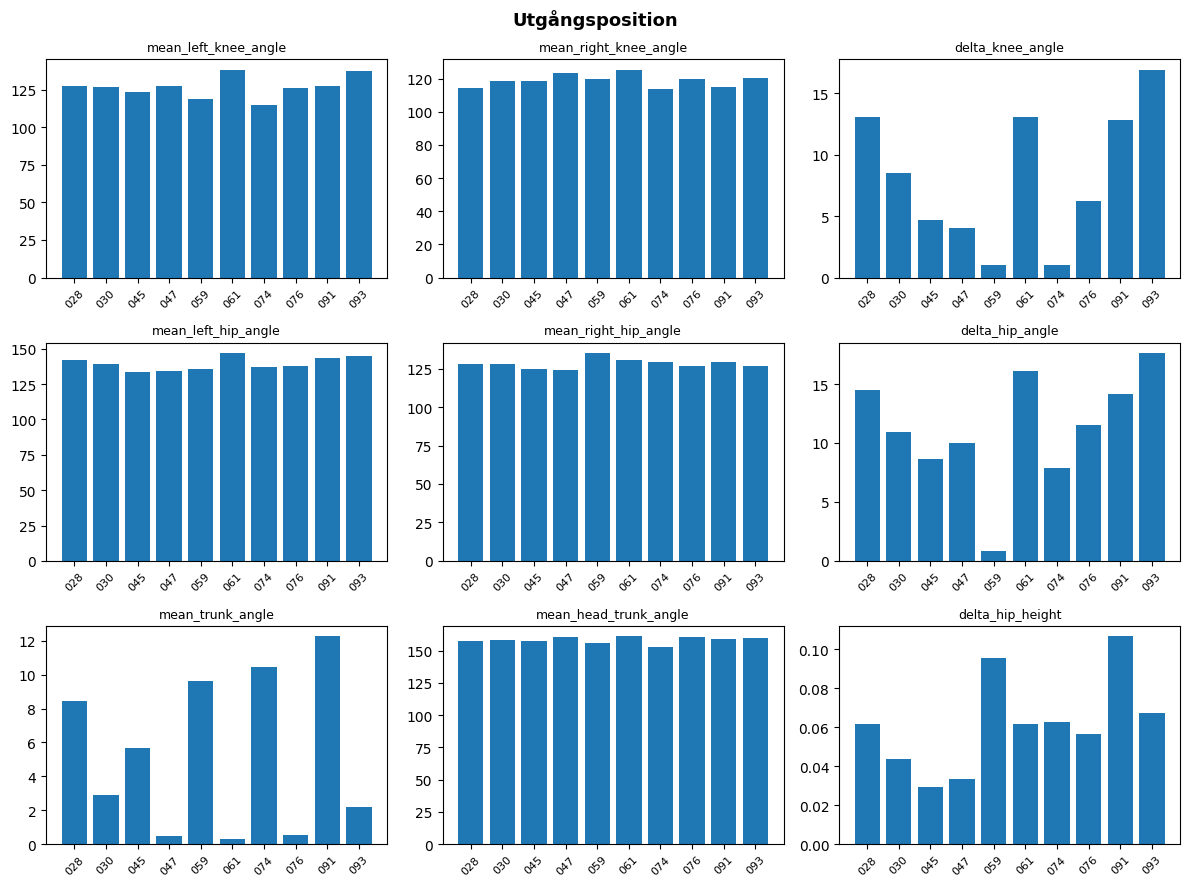

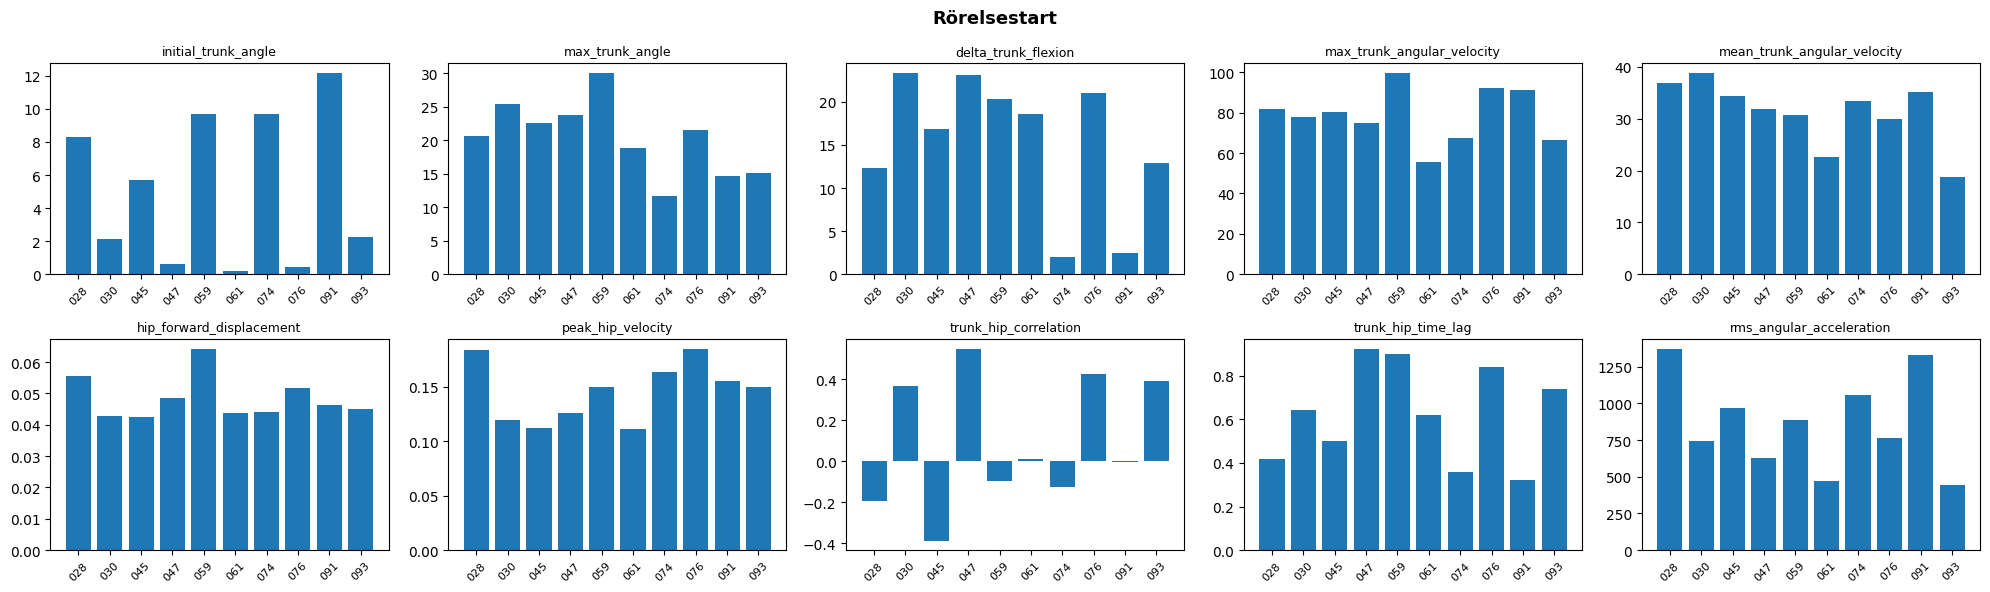

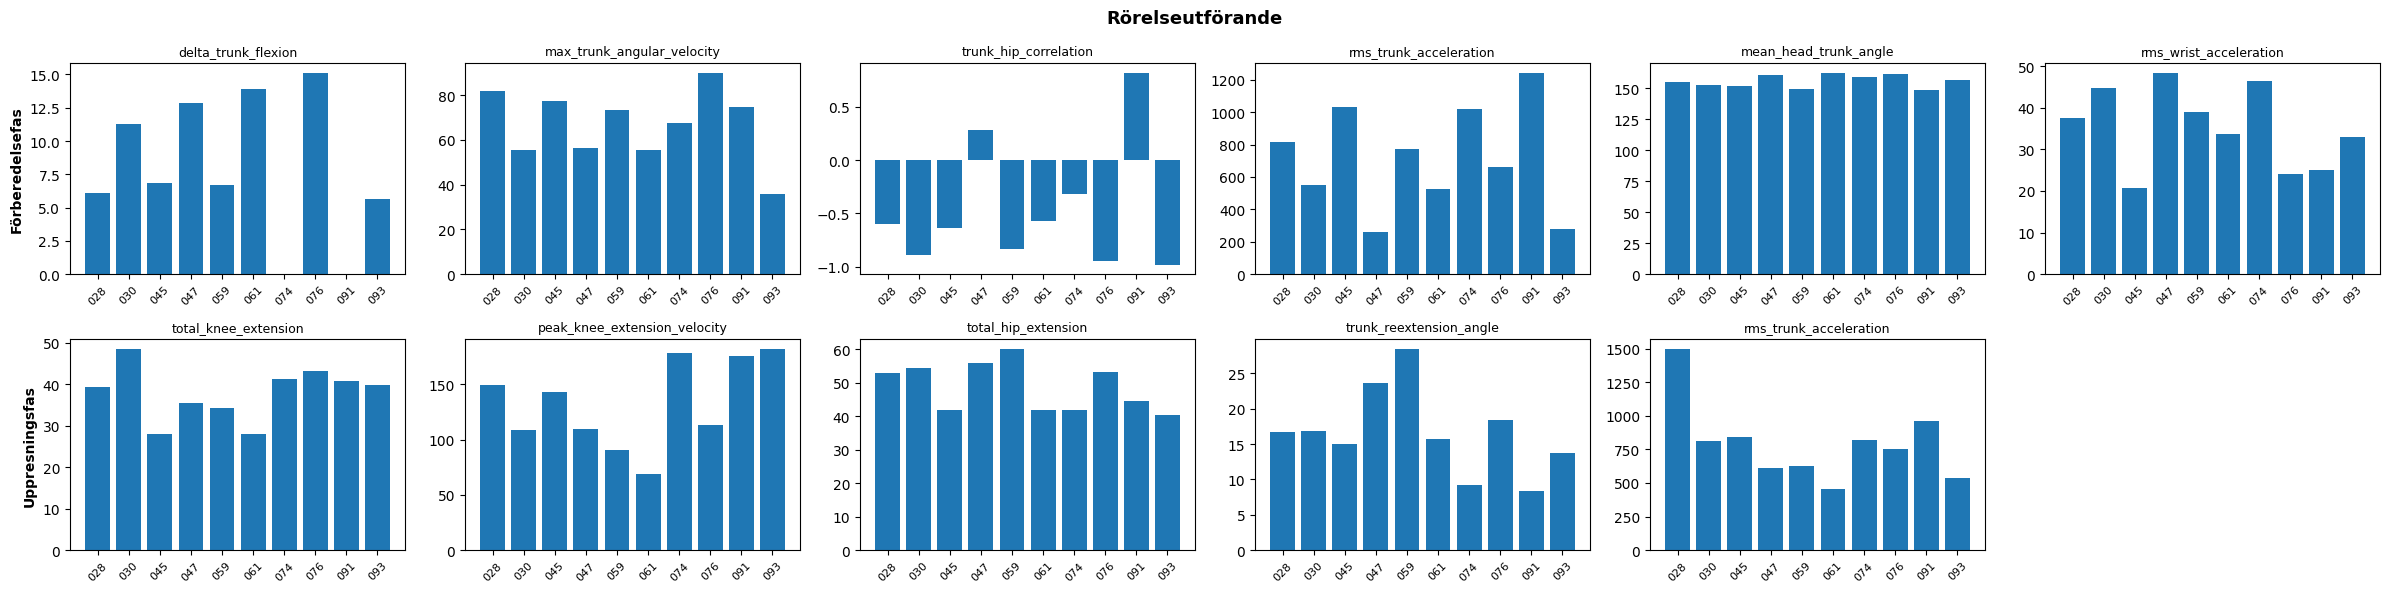

In [40]:
def plot_phase(df, title, ncols, filepath):
    features = df.columns.tolist()
    nrows = (len(features) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes = axes.flatten()
    for i, feat in enumerate(features):
        axes[i].bar(df.index, df[feat])
        axes[i].set_title(feat, fontsize=9)
        axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    fig.savefig(filepath, dpi=150)
    plt.show()

plot_phase(df_utgång, 'Utgångsposition', ncols=3, filepath=OUT_DIR / 'utgångsposition.png')
plot_phase(df_rörelse, 'Rörelsestart',   ncols=5, filepath=OUT_DIR / 'rörelsestart.png')

# Rörelseutförande: two rows, one per sub-phase
forb_cols = [c for c in df_utf.columns if c.startswith('forb_')]
uppr_cols = [c for c in df_utf.columns if c.startswith('uppr_')]
ncols = max(len(forb_cols), len(uppr_cols))

fig, axes = plt.subplots(2, ncols, figsize=(4 * ncols, 6))
for i, feat in enumerate(forb_cols):
    axes[0, i].bar(df_utf.index, df_utf[feat])
    axes[0, i].set_title(feat.replace('forb_', ''), fontsize=9)
    axes[0, i].tick_params(axis='x', rotation=45, labelsize=8)
for i, feat in enumerate(uppr_cols):
    axes[1, i].bar(df_utf.index, df_utf[feat])
    axes[1, i].set_title(feat.replace('uppr_', ''), fontsize=9)
    axes[1, i].tick_params(axis='x', rotation=45, labelsize=8)
for j in range(len(uppr_cols), ncols):
    axes[1, j].set_visible(False)

axes[0, 0].set_ylabel('Förberedelsefas', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Uppresningsfas',  fontsize=10, fontweight='bold')
fig.suptitle('Rörelseutförande', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT_DIR / 'rörelseutförande.png', dpi=150)
plt.show()

## MoLab Features

In [41]:
from pathlib import Path
import pandas as pd

MOLAB_FULL_DIR    = Path('../data/processed/molab')
MOLAB_CROPPED_DIR = Path('../data/processed/molab_cropped')

JOINT_ANGLE_COLS = [c for c in pd.read_csv(MOLAB_CROPPED_DIR / '0028_molab.csv', nrows=0).columns
                    if c.startswith('JointAngle/')]

offsets = {}
for vid in TIME_DICT:
    full = pd.read_csv(MOLAB_FULL_DIR / f'0{vid}_molab.csv')
    pre  = full[full['molab_frame'] < 41]
    offsets[vid] = pre[JOINT_ANGLE_COLS].mean()

display_cols = ['JointAngle/L_knee_X', 'JointAngle/R_knee_X',
                'JointAngle/L_hip_X',  'JointAngle/R_hip_X',
                'JointAngle/pelvis_X', 'JointAngle/pelvis_Y']
offset_df = pd.DataFrame(offsets).T[display_cols].round(1)
offset_df.columns = ['L_knee', 'R_knee', 'L_hip', 'R_hip', 'pelvis_X', 'pelvis_Y']
print("Pre-calibration offsets (absolute joint angles while seated, degrees):")
display(offset_df)

molab_corrected = {}
for vid in TIME_DICT:
    cropped = pd.read_csv(MOLAB_CROPPED_DIR / f'0{vid}_molab.csv')
    corrected = cropped.copy()
    corrected[JOINT_ANGLE_COLS] = cropped[JOINT_ANGLE_COLS] + offsets[vid]
    molab_corrected[vid] = corrected

print(f"\nmolab_corrected: dict with {len(molab_corrected)} videos, ready for feature engineering.")
print("Non-JointAngle columns (gyro, acc) are unchanged.")

Pre-calibration offsets (absolute joint angles while seated, degrees):


,L_knee,R_knee,L_hip,R_hip,pelvis_X,pelvis_Y
028,92.9,95.9,46.3,50.9,-25.6,-0.3
030,98.2,101.7,83.5,89.4,11.8,-3.0
045,82.5,80.2,55.0,57.4,-11.7,-4.9
047,90.4,89.5,95.1,100.7,28.2,0.0
059,95.5,86.3,46.3,46.0,-21.4,-2.7
061,96.8,90.3,76.6,76.2,9.6,-3.3
074,104.8,97.9,71.5,71.2,-2.4,1.4
076,104.8,99.3,99.9,100.0,26.1,1.4
091,83.1,81.0,37.9,43.1,-29.1,-0.4
093,91.7,91.9,97.0,102.7,33.6,-1.1



molab_corrected: dict with 10 videos, ready for feature engineering.
Non-JointAngle columns (gyro, acc) are unchanged.


In [42]:
import numpy as np

def molab_phase(df, t_start, t_end):
    return df[(df['video_time'] >= t_start) & (df['video_time'] <= t_end)]

def rms(x):
    return np.sqrt(np.mean(x ** 2))

def molab_extract_utgångsposition(df, t0, t1):
    p = molab_phase(df, t0, t1)
    lk = p['JointAngle/L_knee_X']
    rk = p['JointAngle/R_knee_X']
    return {
        'mean_L_knee_flexion':  lk.mean(),
        'mean_R_knee_flexion':  rk.mean(),
        'delta_knee_asymmetry': abs(lk.mean() - rk.mean()),
        'mean_L_hip_flexion':   p['JointAngle/L_hip_X'].mean(),
        'mean_R_hip_flexion':   p['JointAngle/R_hip_X'].mean(),
        'mean_pelvis_tilt':     p['JointAngle/pelvis_X'].mean(),
        'mean_pelvis_lateral':  p['JointAngle/pelvis_Y'].abs().mean(),
    }

def molab_extract_rörelsestart(df, t1, t5):
    p = molab_phase(df, t1, t5)
    pelvis_x = p['JointAngle/pelvis_X']
    gyro_x   = p['SegmentGyro/pelvis_X']
    return {
        'initial_pelvis_tilt': pelvis_x.iloc[0] if len(pelvis_x) else np.nan,
        'max_pelvis_tilt':     pelvis_x.max(),
        'delta_pelvis_tilt':   pelvis_x.max() - pelvis_x.min(),
        'peak_pelvis_gyro':    gyro_x.abs().max(),
        'mean_pelvis_gyro':    gyro_x.abs().mean(),
        'hip_flexion_range':   ((p['JointAngle/L_hip_X'].max() - p['JointAngle/L_hip_X'].min()) +
                                (p['JointAngle/R_hip_X'].max() - p['JointAngle/R_hip_X'].min())) / 2,
        'rms_pelvis_acc':      rms(p['SegmentAcc/pelvis_Y'].values),
    }

def molab_extract_rörelseutförande(df, t2, t3, t4, t5):
    forb = molab_phase(df, t2, t3)
    uppr = molab_phase(df, t4, t5)
    lk_up, rk_up = uppr['JointAngle/L_knee_X'], uppr['JointAngle/R_knee_X']
    return {
        'forb_delta_pelvis_tilt':    forb['JointAngle/pelvis_X'].max() - forb['JointAngle/pelvis_X'].min(),
        'forb_peak_pelvis_gyro':     forb['SegmentGyro/pelvis_X'].abs().max(),
        'forb_rms_pelvis_acc':       rms(forb['SegmentAcc/pelvis_Y'].values),
        'uppr_total_knee_extension': ((lk_up.max() - lk_up.min()) + (rk_up.max() - rk_up.min())) / 2,
        'uppr_peak_shank_gyro':      max(uppr['SegmentGyro/L_shank_X'].abs().max(),
                                         uppr['SegmentGyro/R_shank_X'].abs().max()),
        'uppr_total_hip_extension':  ((uppr['JointAngle/L_hip_X'].max() - uppr['JointAngle/L_hip_X'].min()) +
                                      (uppr['JointAngle/R_hip_X'].max() - uppr['JointAngle/R_hip_X'].min())) / 2,
    }

In [43]:
rows_utg, rows_rs, rows_ru = [], [], []

for vid, (t0, t1, t2, t3, t4, t5) in TIME_DICT.items():
    df = molab_corrected[vid]
    rows_utg.append({'video': vid, **molab_extract_utgångsposition(df, t0, t1)})
    rows_rs.append( {'video': vid, **molab_extract_rörelsestart(df, t1, t5)})
    rows_ru.append( {'video': vid, **molab_extract_rörelseutförande(df, t2, t3, t4, t5)})

OUT_DIR = Path('../data/processed/features')

df_molab_utg = pd.DataFrame(rows_utg).set_index('video')
df_molab_rs  = pd.DataFrame(rows_rs).set_index('video')
df_molab_ru  = pd.DataFrame(rows_ru).set_index('video')

df_molab_utg.to_csv(OUT_DIR / 'molab_utgångsposition.csv')
df_molab_rs.to_csv(OUT_DIR  / 'molab_rörelsestart.csv')
df_molab_ru.to_csv(OUT_DIR  / 'molab_rörelseutförande.csv')

print("=== Utgångsposition ==="); display(df_molab_utg.round(2))
print("=== Rörelsestart ===");    display(df_molab_rs.round(2))
print("=== Rörelseutförande ==="); display(df_molab_ru.round(2))

=== Utgångsposition ===


,mean_L_knee_flexion,mean_R_knee_flexion,delta_knee_asymmetry,mean_L_hip_flexion,mean_R_hip_flexion,mean_pelvis_tilt,mean_pelvis_lateral
video,,,,,,,
028,92.87,95.95,3.08,46.35,50.94,-25.65,0.34
030,98.41,101.79,3.38,83.62,89.55,11.70,2.84
045,82.48,80.16,2.32,55.07,57.42,-11.61,4.83
047,90.61,89.62,0.98,95.26,101.03,28.56,0.06
059,95.51,86.23,9.28,45.83,45.41,-21.78,2.50
061,98.95,92.27,6.68,78.76,78.01,9.37,3.43
074,105.55,97.87,7.68,72.11,70.95,-3.08,1.50
076,104.89,99.48,5.42,100.08,100.31,26.25,1.35
091,82.71,80.90,1.81,37.60,42.82,-29.04,0.35


=== Rörelsestart ===


,initial_pelvis_tilt,max_pelvis_tilt,delta_pelvis_tilt,peak_pelvis_gyro,mean_pelvis_gyro,hip_flexion_range,rms_pelvis_acc
video,,,,,,,
028,-25.61,32.92,58.53,234.17,70.04,97.61,0.59
030,11.34,53.12,42.95,127.97,62.88,120.23,0.42
045,-11.60,52.65,64.26,283.58,69.25,77.08,0.65
047,29.46,64.09,43.30,130.84,53.46,117.24,0.34
059,-21.75,38.21,60.82,137.80,32.72,79.58,0.61
061,9.52,44.18,34.66,79.80,31.13,73.71,0.37
074,-5.04,39.86,45.28,406.10,65.05,79.58,0.53
076,26.72,56.56,34.09,96.18,44.06,111.80,0.29
091,-30.11,43.81,75.07,256.18,105.22,96.48,0.74


=== Rörelseutförande ===


,forb_delta_pelvis_tilt,forb_peak_pelvis_gyro,forb_rms_pelvis_acc,uppr_total_knee_extension,uppr_peak_shank_gyro,uppr_total_hip_extension
video,,,,,,
028,46.73,234.17,0.37,82.36,39.43,96.05
030,27.58,125.56,0.22,95.70,34.06,120.23
045,46.68,283.58,0.24,58.88,33.66,74.86
047,20.66,130.84,0.17,78.66,38.88,111.67
059,43.16,137.80,0.21,80.15,35.10,75.25
061,19.66,79.80,0.12,75.59,31.95,73.71
074,35.46,406.10,0.27,78.85,109.41,67.46
076,20.78,95.60,0.18,88.88,45.48,110.83
091,58.09,256.18,0.34,75.65,111.90,91.92


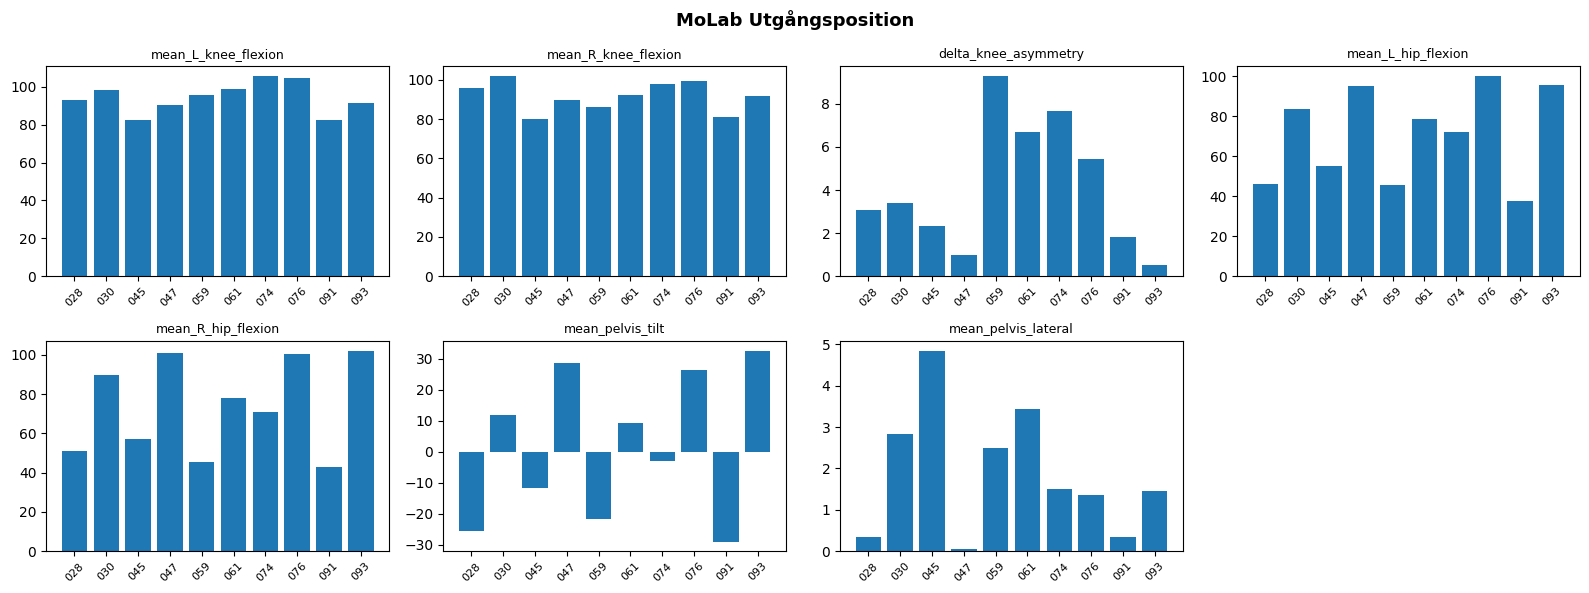

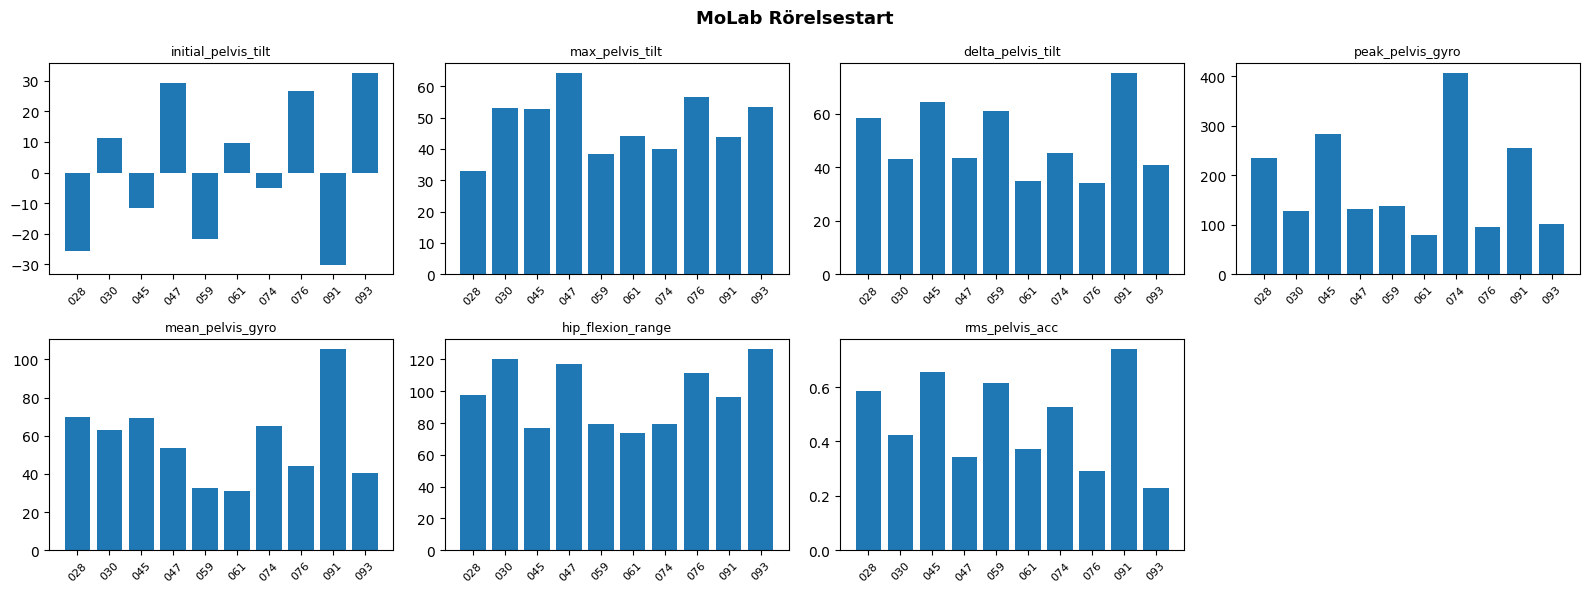

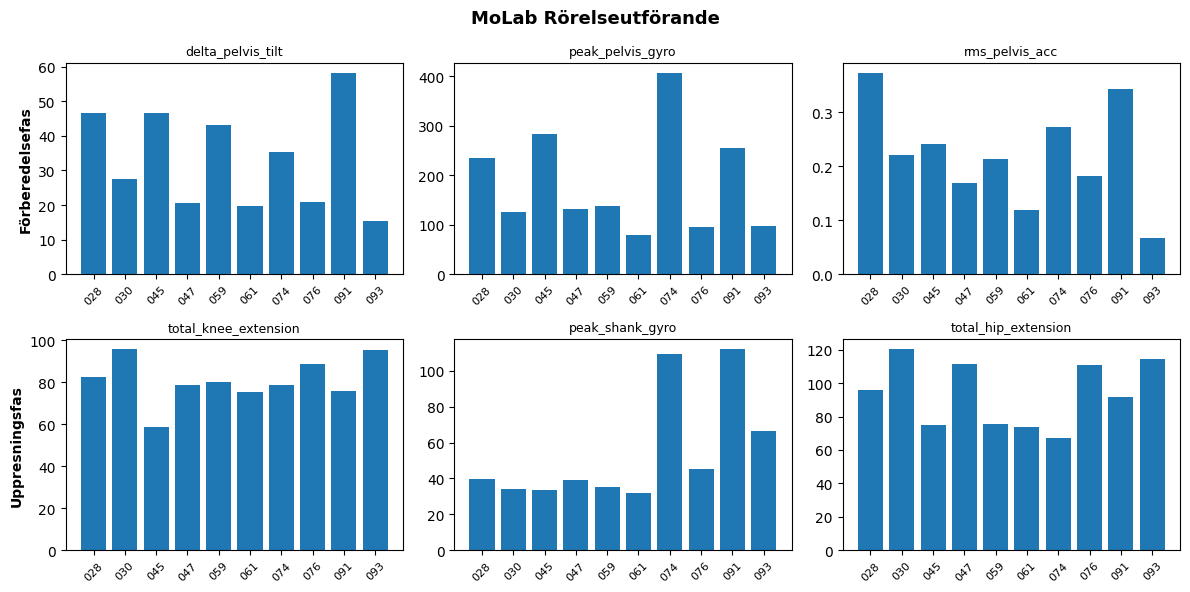

In [44]:
forb_cols = [c for c in df_molab_ru.columns if c.startswith('forb_')]
uppr_cols = [c for c in df_molab_ru.columns if c.startswith('uppr_')]
ncols_ru  = max(len(forb_cols), len(uppr_cols))

plot_phase(df_molab_utg, 'MoLab Utgångsposition', ncols=4, filepath=OUT_DIR / 'molab_utgångsposition.png')
plot_phase(df_molab_rs,  'MoLab Rörelsestart',    ncols=4, filepath=OUT_DIR / 'molab_rörelsestart.png')

fig, axes = plt.subplots(2, ncols_ru, figsize=(4 * ncols_ru, 6))
for i, feat in enumerate(forb_cols):
    axes[0, i].bar(df_molab_ru.index, df_molab_ru[feat])
    axes[0, i].set_title(feat.replace('forb_', ''), fontsize=9)
    axes[0, i].tick_params(axis='x', rotation=45, labelsize=8)
for i, feat in enumerate(uppr_cols):
    axes[1, i].bar(df_molab_ru.index, df_molab_ru[feat])
    axes[1, i].set_title(feat.replace('uppr_', ''), fontsize=9)
    axes[1, i].tick_params(axis='x', rotation=45, labelsize=8)
for j in range(len(uppr_cols), ncols_ru):
    axes[1, j].set_visible(False)
axes[0, 0].set_ylabel('Förberedelsefas', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Uppresningsfas',  fontsize=10, fontweight='bold')
fig.suptitle('MoLab Rörelseutförande', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT_DIR / 'molab_rörelseutförande.png', dpi=150)
plt.show()

# Stand to sit

In [45]:
DOWN_TIME_DICT = {
  '028': (11.87, 11.90, 11.90, 12.57, 12.82),
  '030': (8.07, 9.62, 9.62, 10.64, 11.16),
  '045': (7.94, 7.96, 7.96, 8.74, 9.26),
  '047': (9.20, 10.14, 10.14, 11.10, 11.70),
  '059': (9.11, 9.18, 9.18, 10.37, 11.06),
  '061': (10.57, 10.88, 10.88, 12.26, 13.00),
  '074': (7.27, 7.30, 7.30, 7.88, 8.14),
  '076': (8.27, 8.72, 8.72, 9.73, 10.32),
  '091': (7.56, 7.58, 7.58, 8.09, 8.18),
  '093': (8.50, 9.19, 9.19, 10.08, 10.74),
}

In [46]:
DOWN_IN_DIR      = Path('../data/processed/keypoints_normalized_down')
DOWN_IN_DIR_COMB = Path('../data/processed/keypoints_combined_down')
DOWN_OUT_DIR     = Path('../data/processed/features_down')
DOWN_OUT_DIR.mkdir(parents=True, exist_ok=True)

### Utgångsposition

In [47]:
def extract_utgångsposition_down(df):
    ls, rs = xy(df, 'left_shoulder'), xy(df, 'right_shoulder')
    lh, rh = xy(df, 'left_hip'),      xy(df, 'right_hip')
    lk, rk = xy(df, 'left_knee'),     xy(df, 'right_knee')
    la, ra = xy(df, 'left_ankle'),     xy(df, 'right_ankle')
    nose   = xy(df, 'nose')

    left_knee_a  = compute_angle(lh, lk, la)
    right_knee_a = compute_angle(rh, rk, ra)
    left_hip_a   = compute_angle(ls, lh, lk)
    right_hip_a  = compute_angle(rs, rh, rk)

    mid_shoulder = (ls + rs) / 2
    mid_hip      = (lh + rh) / 2
    trunk_vec    = mid_shoulder - mid_hip
    vertical     = np.array([0, -1])
    trunk_a      = np.degrees(np.arccos(np.clip(
        (trunk_vec * vertical).sum(axis=1) / np.linalg.norm(trunk_vec, axis=1), -1, 1)))

    head_trunk_a = compute_angle(mid_hip, mid_shoulder, nose)

    stance_w = np.linalg.norm(la - ra, axis=1)
    hip_w    = np.linalg.norm(lh - rh, axis=1)
    knee_fwd = ((lk[:, 0] - la[:, 0]) + (rk[:, 0] - ra[:, 0])) / 2

    return {
        'stance_width':          stance_w.mean(),
        'stance_to_hip_ratio':   (stance_w / np.clip(hip_w, 1e-6, None)).mean(),
        'mean_left_knee_angle':  left_knee_a.mean(),
        'mean_right_knee_angle': right_knee_a.mean(),
        'delta_knee_angle':      np.abs(left_knee_a - right_knee_a).mean(),
        'mean_left_hip_angle':   left_hip_a.mean(),
        'mean_right_hip_angle':  right_hip_a.mean(),
        'delta_hip_angle':       np.abs(left_hip_a - right_hip_a).mean(),
        'mean_trunk_angle':      trunk_a.mean(),
        'mean_head_trunk_angle': head_trunk_a.mean(),
        'shoulder_asym':         np.abs(ls[:, 1] - rs[:, 1]).mean(),
        'hip_asym':              np.abs(lh[:, 1] - rh[:, 1]).mean(),
        'knee_asym':             np.abs(lk[:, 1] - rk[:, 1]).mean(),
        'mean_knee_forward':     knee_fwd.mean(),
    }

In [48]:
rows = []
for vid_id, times in DOWN_TIME_DICT.items():
    t0, t1 = times[0], times[1]
    df = pd.read_csv(next(DOWN_IN_DIR.glob(f'*_0{vid_id}_D.csv')))
    phase = get_phase(df, t0, t1)
    rows.append({'video': vid_id, **extract_utgångsposition_down(phase)})

df_down_utgång = pd.DataFrame(rows).set_index('video')
df_down_utgång.to_csv(DOWN_OUT_DIR / 'down_utgångsposition.csv')
display(df_down_utgång.round(2))

,stance_width,stance_to_hip_ratio,mean_left_knee_angle,mean_right_knee_angle,delta_knee_angle,mean_left_hip_angle,mean_right_hip_angle,delta_hip_angle,mean_trunk_angle,mean_head_trunk_angle,shoulder_asym,hip_asym,knee_asym,mean_knee_forward
video,,,,,,,,,,,,,,
028,0.14,1.18,177.56,172.18,5.38,179.70,175.90,3.80,0.61,162.22,0.01,0.01,0.04,-0.05
030,0.14,0.92,179.09,179.19,0.36,177.59,179.06,1.47,0.70,161.46,0.05,0.01,0.02,-0.04
045,0.14,0.91,169.72,173.25,3.53,164.77,166.47,1.70,7.42,163.73,0.01,0.01,0.00,-0.02
047,0.15,1.03,176.09,178.71,2.62,178.72,179.62,0.91,0.25,162.26,0.01,0.01,0.02,-0.04
059,0.11,0.81,177.42,173.94,3.47,179.84,179.40,0.44,1.33,162.83,0.02,0.00,0.05,-0.06
061,0.12,0.72,175.71,174.34,1.38,177.68,179.53,1.85,0.42,164.56,0.05,0.01,0.04,-0.06
074,0.17,1.30,174.28,174.54,0.58,175.29,173.46,1.84,2.03,168.11,0.02,0.00,0.05,-0.03
076,0.11,0.67,178.16,178.69,0.53,176.15,174.10,2.05,1.58,160.66,0.04,0.01,0.03,-0.04
091,0.16,1.12,175.56,177.63,2.07,172.48,170.62,1.87,4.54,162.50,0.01,0.01,0.03,0.01


### Rörelsestart

In [49]:
def extract_rörelsestart_down(df_norm, df_comb):
    ls, rs = xy(df_norm, 'left_shoulder'), xy(df_norm, 'right_shoulder')
    lh, rh = xy(df_norm, 'left_hip'),      xy(df_norm, 'right_hip')
    lk, rk = xy(df_norm, 'left_knee'),     xy(df_norm, 'right_knee')
    la, ra = xy(df_norm, 'left_ankle'),     xy(df_norm, 'right_ankle')

    mid_shoulder = (ls + rs) / 2
    mid_hip      = (lh + rh) / 2
    trunk_vec    = mid_shoulder - mid_hip
    vertical     = np.array([0, -1])
    trunk_a      = np.degrees(np.arccos(np.clip(
        (trunk_vec * vertical).sum(axis=1) / np.linalg.norm(trunk_vec, axis=1), -1, 1)))

    dt           = 1 / 50
    velocity     = np.diff(trunk_a) / dt
    acceleration = np.diff(velocity) / dt

    left_knee_a  = compute_angle(lh, lk, la)
    right_knee_a = compute_angle(rh, rk, ra)
    left_hip_a   = compute_angle(ls, lh, lk)
    right_hip_a  = compute_angle(rs, rh, rk)

    lh_c, rh_c = xy(df_comb, 'left_hip'), xy(df_comb, 'right_hip')
    mid_hip_c   = (lh_c + rh_c) / 2

    return {
        'initial_trunk_angle':         trunk_a[0],
        'max_trunk_angle':             trunk_a.max(),
        'delta_trunk_flexion':         trunk_a.max() - trunk_a[0],
        'peak_trunk_angular_velocity': np.abs(velocity).max(),
        'mean_trunk_angular_velocity': np.abs(velocity).mean(),
        'rms_trunk_acceleration':      np.sqrt(np.mean(acceleration ** 2)),
        'ROM_knee':                    ((left_knee_a.max() - left_knee_a.min()) +
                                        (right_knee_a.max() - right_knee_a.min())) / 2,
        'ROM_hip':                     ((left_hip_a.max() - left_hip_a.min()) +
                                        (right_hip_a.max() - right_hip_a.min())) / 2,
        'hip_descent':                 mid_hip_c[-1, 1] - mid_hip_c[0, 1],
        'hip_backward_displacement':   mid_hip_c[-1, 0] - mid_hip_c[0, 0],
        'trunk_hip_correlation':       np.corrcoef(trunk_a, mid_hip_c[:, 1])[0, 1],
    }

In [50]:
rows = []
for vid_id, times in DOWN_TIME_DICT.items():
    t1, t4 = times[1], times[4]
    df_norm = pd.read_csv(next(DOWN_IN_DIR.glob(f'*_0{vid_id}_D.csv')))
    df_comb = pd.read_csv(next(DOWN_IN_DIR_COMB.glob(f'*_0{vid_id}_D.csv')))
    phase_norm = get_phase(df_norm, t1, t4)
    phase_comb = get_phase(df_comb, t1, t4)
    rows.append({'video': vid_id,
                 **extract_rörelsestart_down(phase_norm, phase_comb),
                 'movement_duration': t4 - t1})

df_down_rörelse = pd.DataFrame(rows).set_index('video')
df_down_rörelse.to_csv(DOWN_OUT_DIR / 'down_rörelsestart.csv')
display(df_down_rörelse.round(4))

,initial_trunk_angle,max_trunk_angle,delta_trunk_flexion,peak_trunk_angular_velocity,mean_trunk_angular_velocity,rms_trunk_acceleration,ROM_knee,ROM_hip,hip_descent,hip_backward_displacement,trunk_hip_correlation,movement_duration
video,,,,,,,,,,,,
028,0.7229,19.7560,19.0331,92.9781,39.9084,1610.9341,57.2044,59.1595,0.1010,0.0438,0.2612,0.92
030,1.1269,22.6193,21.4924,80.8855,30.0868,677.8886,60.3136,54.3222,0.1042,0.0383,-0.0104,1.54
045,7.3818,24.2996,16.9178,88.4982,35.6268,1130.7509,53.9861,49.8891,0.0976,0.0423,-0.2611,1.30
047,0.3578,25.3904,25.0326,71.8148,32.7191,726.3561,51.5740,60.3694,0.0882,0.0503,0.0449,1.56
059,1.2349,25.8134,24.5785,78.1054,27.8280,841.8372,51.4884,58.6923,0.0891,0.0589,0.0343,1.88
061,0.3524,16.8876,16.5353,76.6867,17.8568,651.6780,44.8489,46.6894,0.0826,0.0438,0.0963,2.12
074,1.8493,14.8443,12.9950,73.3397,22.3024,836.8774,56.2226,58.7790,0.1066,0.0326,0.8461,0.84
076,1.6366,14.2719,12.6353,62.5750,19.1079,696.1992,59.3385,54.7702,0.0913,0.0529,0.1702,1.60
091,4.3805,15.4798,11.0993,72.7912,20.9880,815.7582,47.3505,48.3849,0.0912,0.0203,0.8896,0.60


### Rörelseutförande

#### Fas 1 (Inledande nedgående rörelse)

In [51]:
def extract_fas1_down(df_norm, df_comb):
    ls, rs = xy(df_norm, 'left_shoulder'), xy(df_norm, 'right_shoulder')
    lh, rh = xy(df_norm, 'left_hip'),      xy(df_norm, 'right_hip')
    lk, rk = xy(df_norm, 'left_knee'),     xy(df_norm, 'right_knee')
    la, ra = xy(df_norm, 'left_ankle'),     xy(df_norm, 'right_ankle')

    mid_shoulder = (ls + rs) / 2
    mid_hip      = (lh + rh) / 2
    trunk_vec    = mid_shoulder - mid_hip
    vertical     = np.array([0, -1])
    trunk_a      = np.degrees(np.arccos(np.clip(
        (trunk_vec * vertical).sum(axis=1) / np.linalg.norm(trunk_vec, axis=1), -1, 1)))

    left_knee_a  = compute_angle(lh, lk, la)
    right_knee_a = compute_angle(rh, rk, ra)
    left_hip_a   = compute_angle(ls, lh, lk)
    right_hip_a  = compute_angle(rs, rh, rk)

    knee_fwd = ((lk[:, 0] - la[:, 0]) + (rk[:, 0] - ra[:, 0])) / 2

    dt = 1 / 50
    lh_c, rh_c = xy(df_comb, 'left_hip'), xy(df_comb, 'right_hip')
    mid_hip_c   = (lh_c + rh_c) / 2
    hip_vel_y   = np.diff(mid_hip_c[:, 1]) / dt
    hip_acc_y   = np.diff(hip_vel_y) / dt

    lk_c, rk_c = xy(df_comb, 'left_knee'), xy(df_comb, 'right_knee')
    la_c, ra_c = xy(df_comb, 'left_ankle'), xy(df_comb, 'right_ankle')
    knee_fwd_c  = ((lk_c[:, 0] - la_c[:, 0]) + (rk_c[:, 0] - ra_c[:, 0])) / 2

    return {
        'fas1_delta_trunk_angle':      trunk_a[-1] - trunk_a[0],
        'fas1_ROM_trunk':              trunk_a.max() - trunk_a.min(),
        'fas1_ROM_hip':                ((left_hip_a.max() - left_hip_a.min()) +
                                        (right_hip_a.max() - right_hip_a.min())) / 2,
        'fas1_ROM_knee':               ((left_knee_a.max() - left_knee_a.min()) +
                                        (right_knee_a.max() - right_knee_a.min())) / 2,
        'fas1_mean_knee_forward':      knee_fwd.mean(),
        'fas1_delta_knee_forward':     knee_fwd_c[-1] - knee_fwd_c[0],
        'fas1_knee_asym':              np.abs(lk[:, 1] - rk[:, 1]).mean(),
        'fas1_rms_pelvis_acc_y':       np.sqrt(np.mean(hip_acc_y ** 2)),
        'fas1_peak_pelvis_velocity_y': np.abs(hip_vel_y).max(),
    }

#### Fas 2 (Avslutande bakåtgående rörelse)

In [52]:
def extract_fas2_down(df_norm, df_comb):
    lh, rh = xy(df_norm, 'left_hip'),   xy(df_norm, 'right_hip')
    lk, rk = xy(df_norm, 'left_knee'),  xy(df_norm, 'right_knee')
    lw, rw = xy(df_norm, 'left_wrist'), xy(df_norm, 'right_wrist')

    lh_c, rh_c = xy(df_comb, 'left_hip'), xy(df_comb, 'right_hip')
    mid_hip_c   = (lh_c + rh_c) / 2
    hip_x, hip_y = mid_hip_c[:, 0], mid_hip_c[:, 1]

    dt = 1 / 50
    hip_acc_x = np.diff(np.diff(hip_x) / dt) / dt
    hip_acc_y = np.diff(np.diff(hip_y) / dt) / dt

    lw_acc = np.diff(np.diff(lw, axis=0) / dt, axis=0) / dt
    rw_acc = np.diff(np.diff(rw, axis=0) / dt, axis=0) / dt
    rms_wrist = (np.sqrt(np.mean(np.linalg.norm(lw_acc, axis=1) ** 2)) +
                 np.sqrt(np.mean(np.linalg.norm(rw_acc, axis=1) ** 2))) / 2

    return {
        'fas2_pelvis_backward_displacement': hip_x[-1] - hip_x[0],
        'fas2_pelvis_descent':               hip_y[-1] - hip_y[0],
        'fas2_rms_pelvis_acc_x':             np.sqrt(np.mean(hip_acc_x ** 2)),
        'fas2_rms_pelvis_acc_y':             np.sqrt(np.mean(hip_acc_y ** 2)),
        'fas2_hip_asym':                     np.abs(lh[:, 1] - rh[:, 1]).mean(),
        'fas2_knee_asym':                    np.abs(lk[:, 1] - rk[:, 1]).mean(),
        'fas2_rms_wrist_acceleration':       rms_wrist,
    }

In [53]:
rows = []
for vid_id, times in DOWN_TIME_DICT.items():
    t2, t3, t4 = times[2], times[3], times[4]
    df_norm = pd.read_csv(next(DOWN_IN_DIR.glob(f'*_0{vid_id}_D.csv')))
    df_comb = pd.read_csv(next(DOWN_IN_DIR_COMB.glob(f'*_0{vid_id}_D.csv')))
    phase_fas1_norm = get_phase(df_norm, t2, t3)
    phase_fas1_comb = get_phase(df_comb, t2, t3)
    phase_fas2_norm = get_phase(df_norm, t3, t4)
    phase_fas2_comb = get_phase(df_comb, t3, t4)
    rows.append({'video': vid_id,
                 **extract_fas1_down(phase_fas1_norm, phase_fas1_comb),
                 **extract_fas2_down(phase_fas2_norm, phase_fas2_comb),
                 'fas1_phase_duration': t3 - t2,
                 'fas2_phase_duration': t4 - t3})

df_down_utf = pd.DataFrame(rows).set_index('video')
df_down_utf.to_csv(DOWN_OUT_DIR / 'down_rörelseutförande.csv')
display(df_down_utf.round(4))

,fas1_delta_trunk_angle,fas1_ROM_trunk,fas1_ROM_hip,fas1_ROM_knee,fas1_mean_knee_forward,fas1_delta_knee_forward,fas1_knee_asym,fas1_rms_pelvis_acc_y,fas1_peak_pelvis_velocity_y,fas2_pelvis_backward_displacement,fas2_pelvis_descent,fas2_rms_pelvis_acc_x,fas2_rms_pelvis_acc_y,fas2_hip_asym,fas2_knee_asym,fas2_rms_wrist_acceleration,fas1_phase_duration,fas2_phase_duration
video,,,,,,,,,,,,,,,,,,
028,8.6685,19.0331,50.3073,48.0657,-0.1182,-0.0110,0.0613,8.8893,0.4810,0.0061,0.0005,4.0430,5.1589,0.0448,0.1203,40.1512,0.67,0.25
030,6.2430,21.4968,52.7695,54.5992,-0.1169,-0.0171,0.0510,4.4013,0.3014,0.0025,0.0010,0.8234,1.3631,0.0594,0.1151,17.6891,1.02,0.52
045,1.6936,16.9747,49.8891,47.4635,-0.0707,-0.0082,0.0530,2.7095,0.2511,0.0130,-0.0010,2.4478,1.8713,0.0368,0.1357,20.9031,0.78,0.52
047,13.3144,25.0326,59.7842,46.8482,-0.0935,-0.0062,0.0798,3.7650,0.2905,0.0071,0.0015,1.2278,1.1412,0.0631,0.1172,25.6348,0.96,0.60
059,10.7195,24.7485,58.6923,47.8562,-0.1028,-0.0013,0.0850,3.0113,0.2723,0.0059,-0.0042,0.8553,2.0109,0.0760,0.1364,20.6069,1.19,0.69
061,5.6679,16.8845,46.4624,42.5188,-0.1193,-0.0054,0.0794,2.5598,0.2091,0.0015,0.0052,0.8175,1.5814,0.0637,0.1688,25.8843,1.38,0.74
074,11.6799,13.0006,52.2076,50.2239,-0.1386,-0.0203,0.0462,2.9507,0.4529,0.0101,0.0047,2.4249,4.3099,0.0485,0.0963,38.1398,0.58,0.26
076,6.3056,14.2545,54.7702,57.0781,-0.1377,-0.0155,0.0693,3.7434,0.3216,0.0052,-0.0007,1.3142,1.7060,0.0470,0.1046,18.5158,1.01,0.59
091,10.3959,11.3097,48.1829,47.1715,-0.0841,-0.0192,0.1002,3.4727,0.4348,0.0014,-0.0002,2.2482,6.4450,0.0618,0.1599,116.0929,0.51,0.09


### Plots

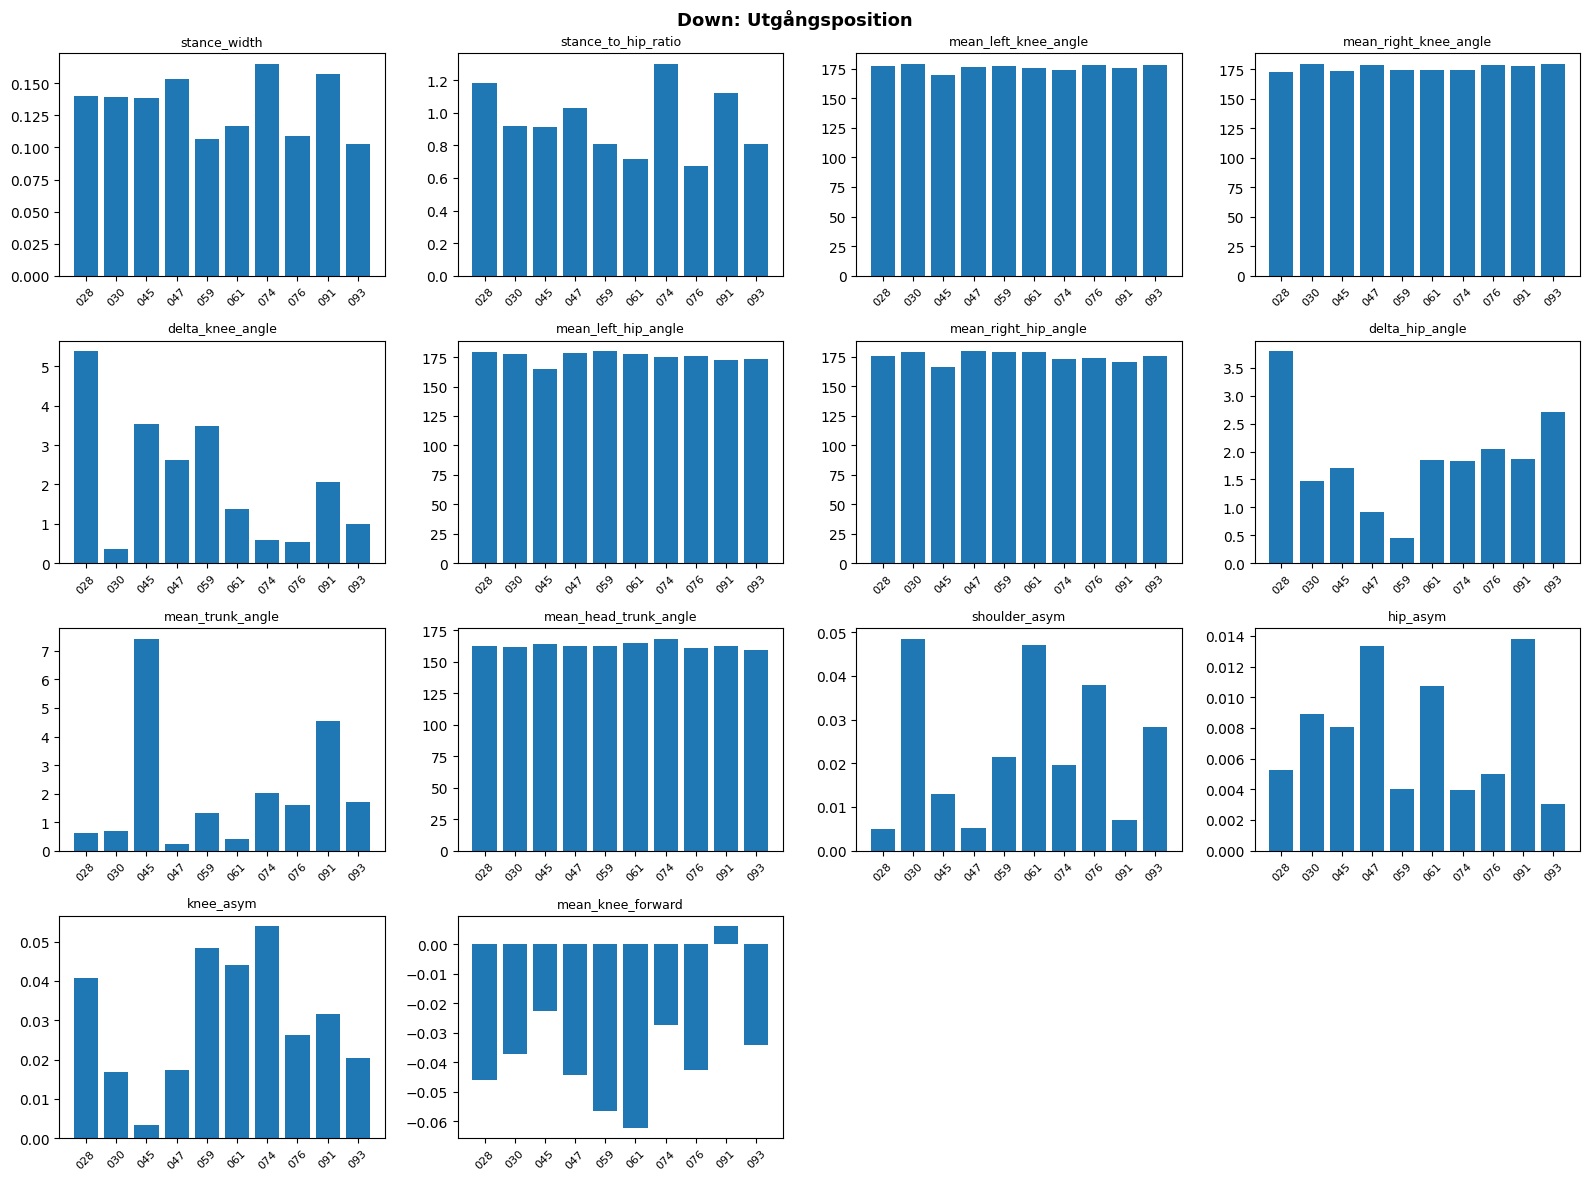

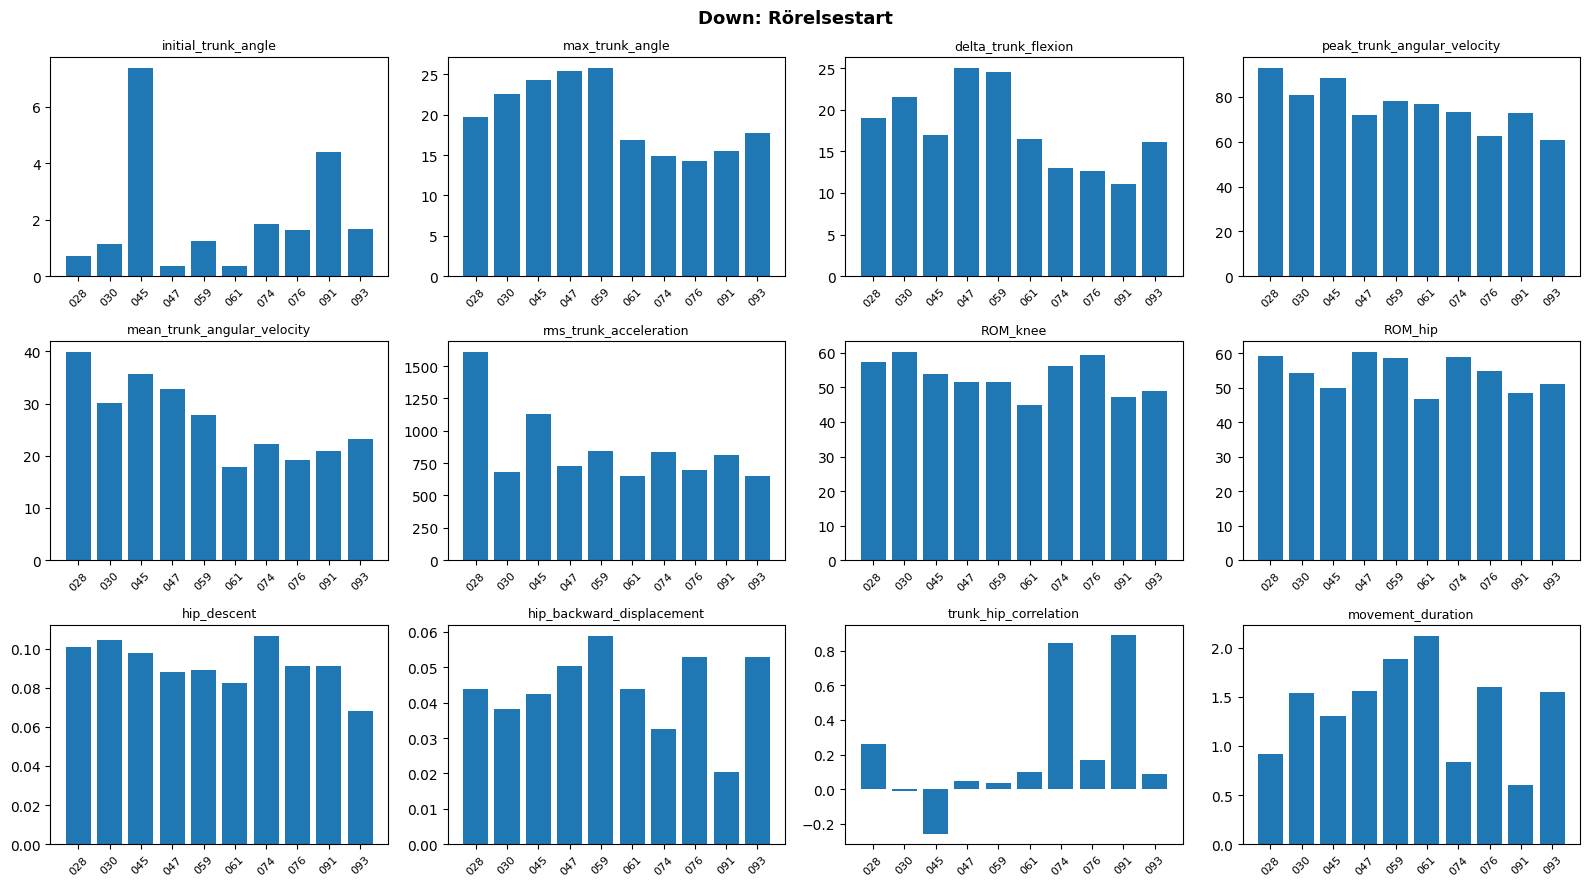

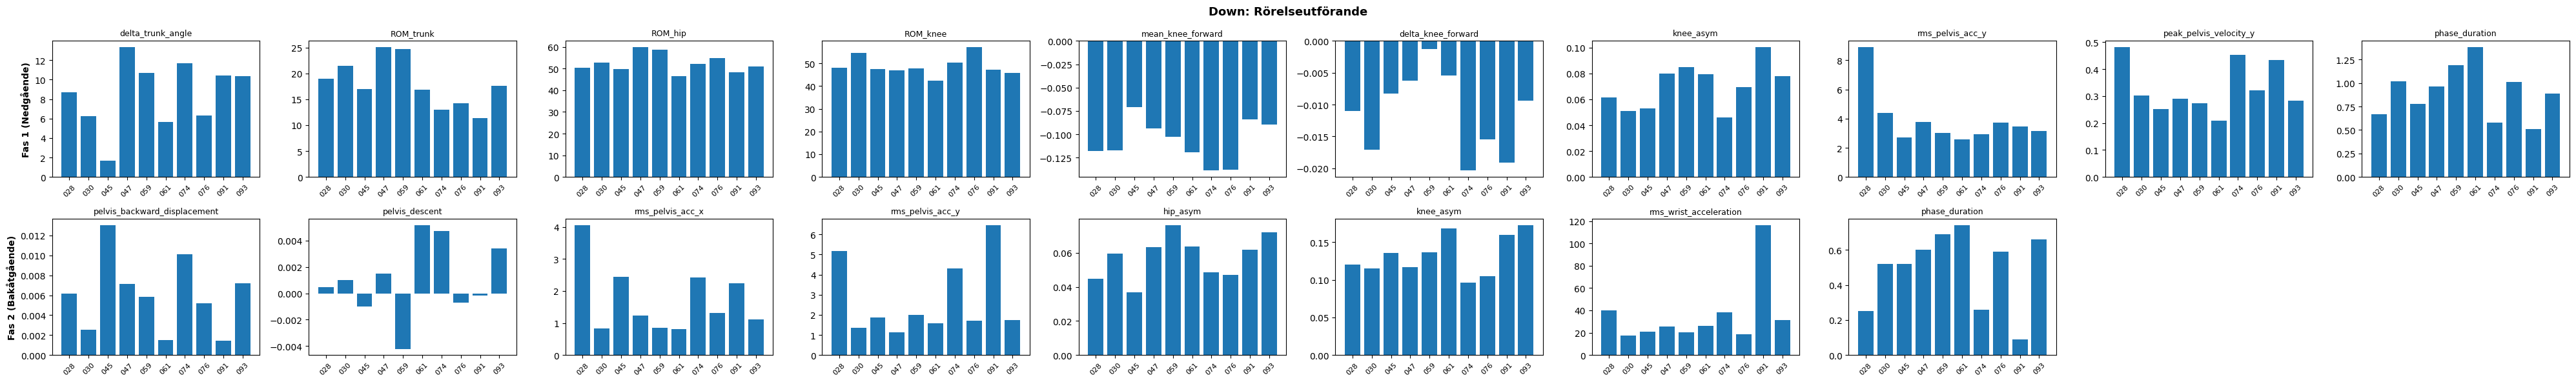

In [54]:
plot_phase(df_down_utgång,  'Down: Utgångsposition',   ncols=4, filepath=DOWN_OUT_DIR / 'down_utgångsposition.png')
plot_phase(df_down_rörelse, 'Down: Rörelsestart',      ncols=4, filepath=DOWN_OUT_DIR / 'down_rörelsestart.png')

fas1_cols = [c for c in df_down_utf.columns if c.startswith('fas1_')]
fas2_cols = [c for c in df_down_utf.columns if c.startswith('fas2_')]
ncols_utf = max(len(fas1_cols), len(fas2_cols))

fig, axes = plt.subplots(2, ncols_utf, figsize=(4 * ncols_utf, 6))
for i, feat in enumerate(fas1_cols):
    axes[0, i].bar(df_down_utf.index, df_down_utf[feat])
    axes[0, i].set_title(feat.replace('fas1_', ''), fontsize=9)
    axes[0, i].tick_params(axis='x', rotation=45, labelsize=8)
for i, feat in enumerate(fas2_cols):
    axes[1, i].bar(df_down_utf.index, df_down_utf[feat])
    axes[1, i].set_title(feat.replace('fas2_', ''), fontsize=9)
    axes[1, i].tick_params(axis='x', rotation=45, labelsize=8)
for ax in axes.flatten():
    if not ax.has_data():
        ax.set_visible(False)
axes[0, 0].set_ylabel('Fas 1 (Nedgående)', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Fas 2 (Bakåtgående)', fontsize=10, fontweight='bold')
fig.suptitle('Down: Rörelseutförande', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(DOWN_OUT_DIR / 'down_rörelseutförande.png', dpi=150)
plt.show()

## MoLab Features

In [55]:
MOLAB_DOWN_DIR = Path('../data/processed/molab_cropped_down')

molab_corrected_down = {}
for vid in DOWN_TIME_DICT:
    cropped   = pd.read_csv(MOLAB_DOWN_DIR / f'0{vid}_molab.csv')
    corrected = cropped.copy()
    corrected[JOINT_ANGLE_COLS] = cropped[JOINT_ANGLE_COLS] + offsets[vid]
    molab_corrected_down[vid] = corrected

In [56]:
def molab_extract_down_utgångsposition(df, t0, t1):
    p = molab_phase(df, t0, t1)
    lk, rk = p['JointAngle/L_knee_X'], p['JointAngle/R_knee_X']
    return {
        'mean_L_knee_flexion':  lk.mean(),
        'mean_R_knee_flexion':  rk.mean(),
        'delta_knee_asymmetry': abs(lk.mean() - rk.mean()),
        'mean_L_hip_flexion':   p['JointAngle/L_hip_X'].mean(),
        'mean_R_hip_flexion':   p['JointAngle/R_hip_X'].mean(),
        'mean_pelvis_tilt':     p['JointAngle/pelvis_X'].mean(),
        'mean_pelvis_lateral':  p['JointAngle/pelvis_Y'].abs().mean(),
        'mean_L_ankle_flexion': p['JointAngle/L_ankle_X'].mean(),
        'mean_R_ankle_flexion': p['JointAngle/R_ankle_X'].mean(),
    }

def molab_extract_down_rörelsestart(df, t1, t4):
    p        = molab_phase(df, t1, t4)
    pelvis_x = p['JointAngle/pelvis_X']
    gyro_x   = p['SegmentGyro/pelvis_X']
    return {
        'ROM_knee':          ((p['JointAngle/L_knee_X'].max() - p['JointAngle/L_knee_X'].min()) +
                               (p['JointAngle/R_knee_X'].max() - p['JointAngle/R_knee_X'].min())) / 2,
        'ROM_hip':           ((p['JointAngle/L_hip_X'].max() - p['JointAngle/L_hip_X'].min()) +
                               (p['JointAngle/R_hip_X'].max() - p['JointAngle/R_hip_X'].min())) / 2,
        'delta_pelvis_tilt': pelvis_x.max() - pelvis_x.min(),
        'peak_pelvis_gyro':  gyro_x.abs().max(),
        'mean_pelvis_gyro':  gyro_x.abs().mean(),
        'rms_pelvis_acc':    rms(p['SegmentAcc/pelvis_Y'].values),
    }

def molab_extract_down_rörelseutförande(df, t2, t3, t4):
    fas1 = molab_phase(df, t2, t3)
    fas2 = molab_phase(df, t3, t4)
    return {
        'fas1_ROM_hip':          ((fas1['JointAngle/L_hip_X'].max() - fas1['JointAngle/L_hip_X'].min()) +
                                   (fas1['JointAngle/R_hip_X'].max() - fas1['JointAngle/R_hip_X'].min())) / 2,
        'fas1_ROM_knee':         ((fas1['JointAngle/L_knee_X'].max() - fas1['JointAngle/L_knee_X'].min()) +
                                   (fas1['JointAngle/R_knee_X'].max() - fas1['JointAngle/R_knee_X'].min())) / 2,
        'fas1_knee_angle_diff':  (fas1['JointAngle/L_knee_X'] - fas1['JointAngle/R_knee_X']).abs().mean(),
        'fas1_rms_pelvis_acc':   rms(fas1['SegmentAcc/pelvis_Y'].values),
        'fas1_peak_shank_gyro':  max(fas1['SegmentGyro/L_shank_X'].abs().max(),
                                     fas1['SegmentGyro/R_shank_X'].abs().max()),
        'fas1_pelvis_lateral':   fas1['JointAngle/pelvis_Y'].abs().mean(),
        'fas1_peak_thigh_gyro':  max(fas1['SegmentGyro/L_thigh_X'].abs().max(),
                                     fas1['SegmentGyro/R_thigh_X'].abs().max()),
        'fas2_pelvis_lateral':   fas2['JointAngle/pelvis_Y'].abs().mean(),
        'fas2_rms_pelvis_acc':   rms(fas2['SegmentAcc/pelvis_Y'].values),
        'fas2_peak_pelvis_gyro': fas2['SegmentGyro/pelvis_X'].abs().max(),
        'fas2_ROM_knee':         ((fas2['JointAngle/L_knee_X'].max() - fas2['JointAngle/L_knee_X'].min()) +
                                   (fas2['JointAngle/R_knee_X'].max() - fas2['JointAngle/R_knee_X'].min())) / 2,
        'fas2_ROM_hip':          ((fas2['JointAngle/L_hip_X'].max() - fas2['JointAngle/L_hip_X'].min()) +
                                   (fas2['JointAngle/R_hip_X'].max() - fas2['JointAngle/R_hip_X'].min())) / 2,
    }

In [57]:
rows_utg, rows_rs, rows_ru = [], [], []

for vid, (t0, t1, t2, t3, t4) in DOWN_TIME_DICT.items():
    df = molab_corrected_down[vid]
    rows_utg.append({'video': vid, **molab_extract_down_utgångsposition(df, t0, t1)})
    rows_rs.append( {'video': vid, **molab_extract_down_rörelsestart(df, t1, t4)})
    rows_ru.append( {'video': vid, **molab_extract_down_rörelseutförande(df, t2, t3, t4)})

df_down_molab_utg = pd.DataFrame(rows_utg).set_index('video')
df_down_molab_rs  = pd.DataFrame(rows_rs).set_index('video')
df_down_molab_ru  = pd.DataFrame(rows_ru).set_index('video')

df_down_molab_utg.to_csv(DOWN_OUT_DIR / 'down_molab_utgångsposition.csv')
df_down_molab_rs.to_csv(DOWN_OUT_DIR  / 'down_molab_rörelsestart.csv')
df_down_molab_ru.to_csv(DOWN_OUT_DIR  / 'down_molab_rörelseutförande.csv')

print("=== Utgångsposition ==="); display(df_down_molab_utg.round(2))
print("=== Rörelsestart ===");    display(df_down_molab_rs.round(2))
print("=== Rörelseutförande ==="); display(df_down_molab_ru.round(4))

=== Utgångsposition ===


,mean_L_knee_flexion,mean_R_knee_flexion,delta_knee_asymmetry,mean_L_hip_flexion,mean_R_hip_flexion,mean_pelvis_tilt,mean_pelvis_lateral,mean_L_ankle_flexion,mean_R_ankle_flexion
video,,,,,,,,,
028,3.57,5.84,2.27,-2.07,2.78,7.86,1.74,65.46,62.94
030,-1.42,2.96,4.38,-5.19,2.94,13.25,2.15,68.58,65.69
045,14.14,10.41,3.73,27.63,30.94,28.43,1.48,73.30,64.64
047,-5.94,-6.58,0.64,-4.54,1.48,19.80,0.66,76.07,69.63
059,-0.94,-5.98,5.04,9.91,10.87,31.40,8.20,72.25,64.32
061,1.81,0.04,1.77,10.19,12.87,31.25,4.21,75.48,70.03
074,10.94,3.66,7.29,21.75,21.40,26.20,3.29,74.41,66.10
076,-5.18,-7.11,1.94,-0.02,0.77,24.52,0.92,77.13,70.97
091,1.17,-2.19,3.36,9.62,13.98,16.59,2.08,58.49,53.22


=== Rörelsestart ===


,ROM_knee,ROM_hip,delta_pelvis_tilt,peak_pelvis_gyro,mean_pelvis_gyro,rms_pelvis_acc
video,,,,,,
028,95.43,91.64,36.68,116.04,65.57,0.72
030,101.44,100.82,36.03,99.88,41.39,0.32
045,73.06,82.77,69.38,483.50,75.90,0.84
047,89.95,110.34,49.75,108.71,59.35,0.38
059,91.94,83.29,38.77,79.37,31.70,0.70
061,90.15,72.68,40.01,101.01,26.62,0.31
074,94.52,98.36,29.16,258.38,53.80,0.81
076,107.48,105.39,34.51,108.32,40.22,0.24
091,85.92,93.01,29.66,122.63,58.66,1.06


=== Rörelseutförande ===


,fas1_ROM_hip,fas1_ROM_knee,fas1_knee_angle_diff,fas1_rms_pelvis_acc,fas1_peak_shank_gyro,fas1_pelvis_lateral,fas1_peak_thigh_gyro,fas2_pelvis_lateral,fas2_rms_pelvis_acc,fas2_peak_pelvis_gyro,fas2_ROM_knee,fas2_ROM_hip
video,,,,,,,,,,,,
028,91.6405,95.1020,2.1902,0.8077,62.513,2.7478,208.973,4.1452,0.4051,78.379,1.6650,10.2110
030,100.8240,100.4175,6.1262,0.3962,52.528,3.2427,143.262,4.5942,0.0484,76.209,1.3650,11.4895
045,82.7730,72.4765,2.0524,0.9110,48.380,0.8680,113.033,0.7263,0.7265,483.498,2.3720,41.5185
047,110.3370,88.4585,2.8550,0.4780,43.476,1.7763,142.506,0.2722,0.1126,91.558,1.8495,24.2135
059,83.2935,91.8645,7.9103,0.8052,24.107,6.1276,121.115,4.4873,0.4541,53.218,0.6995,10.3310
061,72.6760,87.7675,7.0752,0.3744,38.507,2.7431,93.232,2.8263,0.1475,101.006,2.7935,15.5275
074,94.3850,89.8740,8.0900,0.8400,97.647,2.6948,177.313,0.3483,0.7222,67.899,4.6775,4.5130
076,105.3900,104.5025,5.2612,0.2793,53.560,1.5033,120.934,0.6964,0.1337,56.067,2.7430,17.6985
091,93.0130,85.9205,1.7603,1.1037,111.899,0.9982,228.109,2.2205,0.7731,38.473,0.4590,2.7625


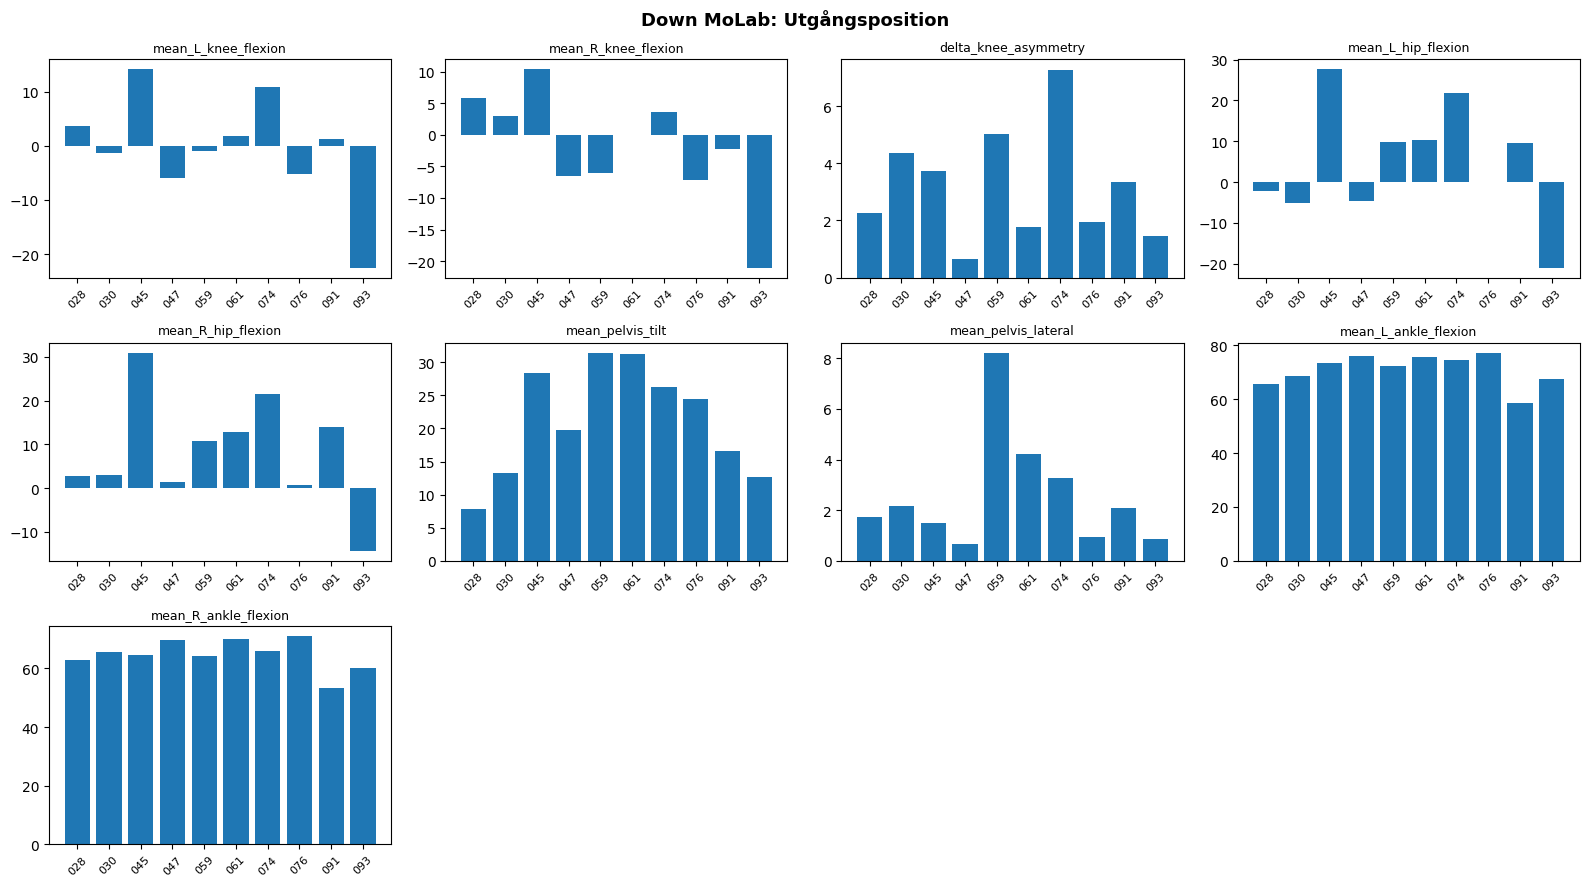

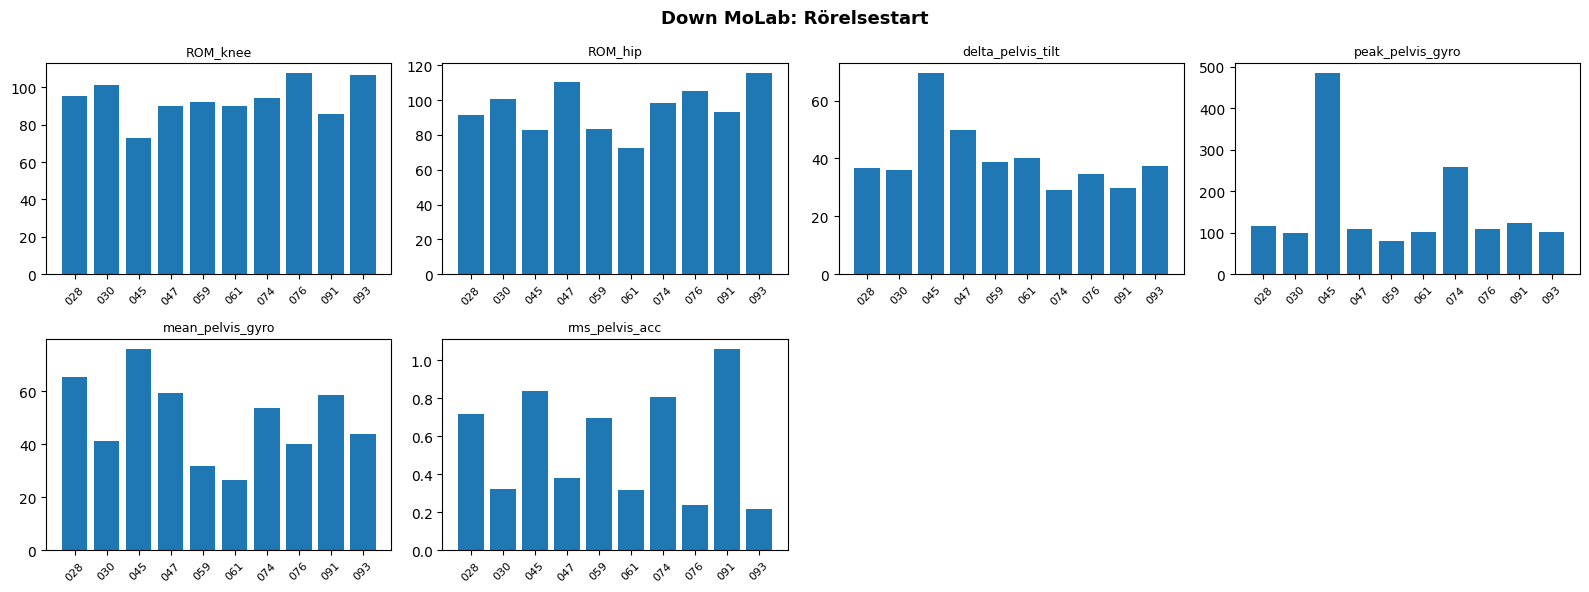

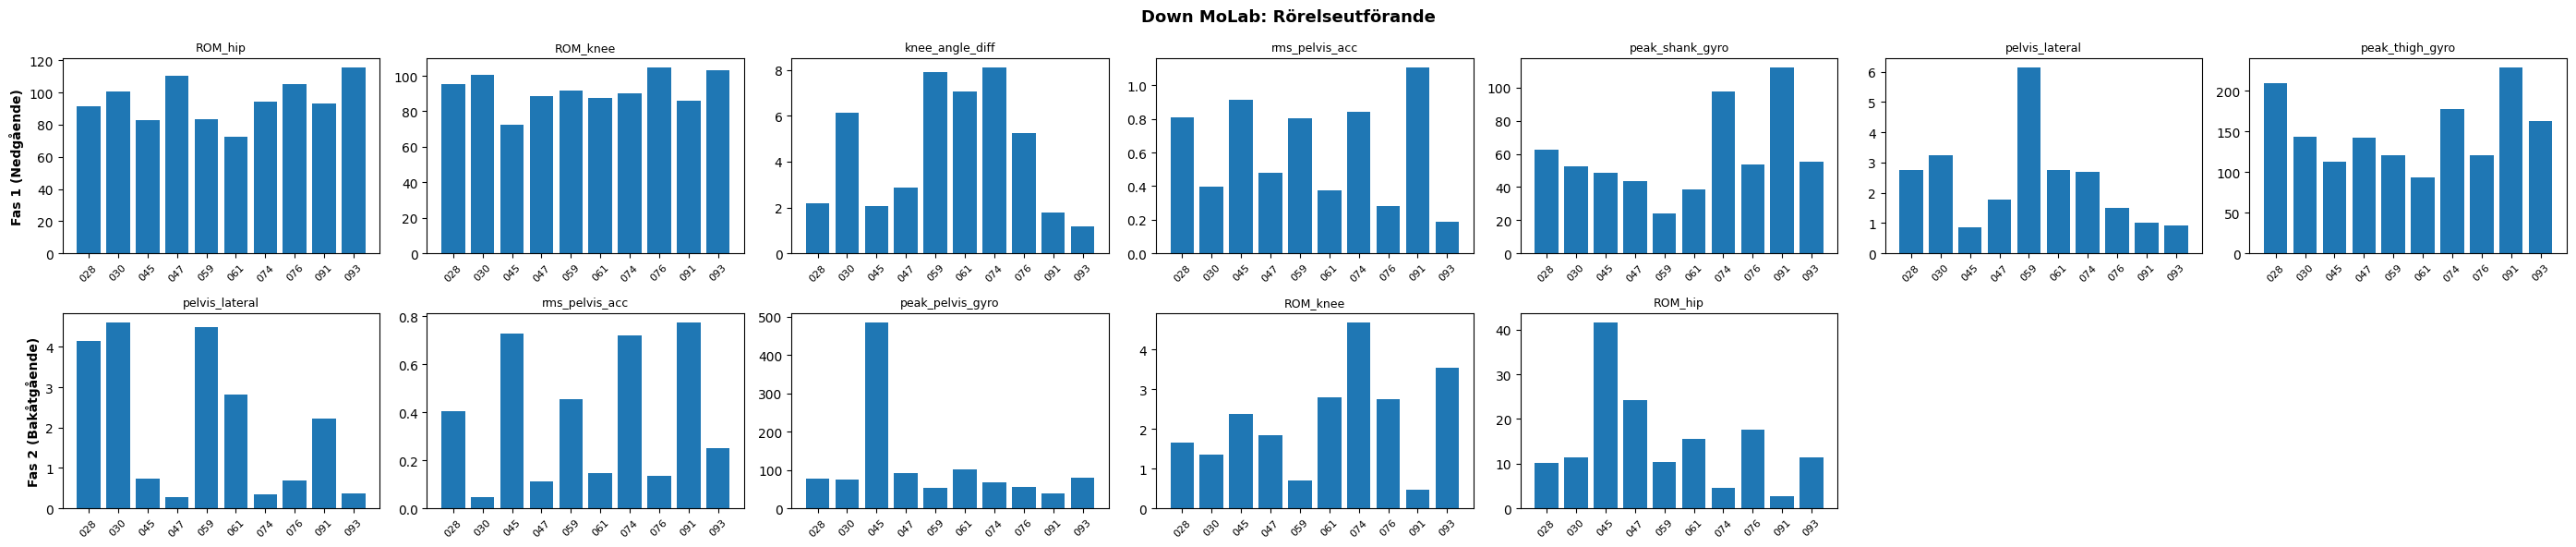

In [58]:
fas1_cols = [c for c in df_down_molab_ru.columns if c.startswith('fas1_')]
fas2_cols = [c for c in df_down_molab_ru.columns if c.startswith('fas2_')]
ncols_ru  = max(len(fas1_cols), len(fas2_cols))

plot_phase(df_down_molab_utg, 'Down MoLab: Utgångsposition', ncols=4, filepath=DOWN_OUT_DIR / 'down_molab_utgångsposition.png')
plot_phase(df_down_molab_rs,  'Down MoLab: Rörelsestart',    ncols=4, filepath=DOWN_OUT_DIR / 'down_molab_rörelsestart.png')

fig, axes = plt.subplots(2, ncols_ru, figsize=(4 * ncols_ru, 6))
for i, feat in enumerate(fas1_cols):
    axes[0, i].bar(df_down_molab_ru.index, df_down_molab_ru[feat])
    axes[0, i].set_title(feat.replace('fas1_', ''), fontsize=9)
    axes[0, i].tick_params(axis='x', rotation=45, labelsize=8)
for i, feat in enumerate(fas2_cols):
    axes[1, i].bar(df_down_molab_ru.index, df_down_molab_ru[feat])
    axes[1, i].set_title(feat.replace('fas2_', ''), fontsize=9)
    axes[1, i].tick_params(axis='x', rotation=45, labelsize=8)
for ax in axes.flatten():
    if not ax.has_data():
        ax.set_visible(False)
axes[0, 0].set_ylabel('Fas 1 (Nedgående)', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Fas 2 (Bakåtgående)', fontsize=10, fontweight='bold')
fig.suptitle('Down MoLab: Rörelseutförande', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(DOWN_OUT_DIR / 'down_molab_rörelseutförande.png', dpi=150)
plt.show()